**Two prices, two outcomes.** This notebook carries the analysis behind our trial presentation
for DATA7001, on the 50-cent fare, fuel prices, public transport patronage and cars in
Queensland. It is organised along the **five steps of the data science process** the brief asks
for. All five steps feed the *Completeness* criterion (30%), while the framing and the honesty
of the interpretation carry *Creativity and innovation* (30%). The table below sets out which
step speaks most directly to each remaining criterion.

| Step | Section | Speaks most directly to |
|---|---|---|
| 1. Problem solving with data | Step 1 | *Aims* — research questions clearly specified |
| 2. Getting the data I need | Step 2 | *Data* — source, size, attributes |
| 3. Is my data fit for use? | Step 3 | *Data* — quality, missing data and how we managed it |
| 4. Making the data confess | Step 4 | *Completeness* — the analysis itself |
| 5. Storytelling with data | Step 5 | *Creativity* — what it means for stakeholders |

**The idea in one line.** A fare is a price and petrol is a price. If people respond to prices
when choosing how to travel, then cutting the fare and moving the petrol price should show up
in the same two places: how many trips are taken, and how many cars are bought.

---

**Step 1 — problem solving with data.** In August 2024 the Queensland Government cut public
transport fares in Southeast Queensland to a flat **50 cents** — first as a six-month trial,
then made permanent in February 2025. It is an expensive policy, and the public case for it was
partly environmental: get people out of cars. Whether it worked, and whether the mechanism
people assumed (expensive driving pushes people onto trains) is the mechanism that actually
operates, are separate questions, and what each stakeholder needs from the answer differs.

| Stakeholder | What they need from this |
|---|---|
| Queensland Treasury / Translink | Did patronage actually respond, and does it persist? |
| Department of Transport and Main Roads | Is the fare a substitute for, or independent of, fuel-price effects? |
| Motorists and households | Does a fare cut change car-buying decisions, or only trip-taking? |
| Environmental policy | Is the emissions story real, or are new trips mostly discretionary outings? |

We settled on five research questions, each stated with the decision it informs and the
comparison that answers it. **RQ1 — description.** How did the fare, patronage, the fuel price
and car registrations each move over December 2023 – May 2026? This is answered by the
four-series view in §4.1, which is what tells us whether the other four questions are worth
asking at all. **RQ2 — did the fare work?** Did the 50-cent fare lift public transport
patronage, and did the lift persist once the fare became permanent in February 2025? This is
answered by same-month-year-earlier change by mode (§4.3); the persistence half matters because
a trial invites a novelty response that a permanent policy does not. **RQ3 — did the fare reach
car ownership?** Did the fare cut flow through to fewer new vehicles registered? This is
answered by the registration series alongside the fare step (§4.4), and it is the mechanism the
policy's environmental case assumes. **RQ4 — does the fuel price act, and on which outcome?**
Does the fuel price move patronage or car-buying, and is that the same outcome the fare moved,
or a different one? This is answered by the fuel price against both outcomes, in levels and
year-on-year (§4.2, §4.4). **RQ5 — do the two prices combine?** Together, do the fare and the
fuel price explain more than either does alone? This is answered by one regression per outcome
with both prices on the right-hand side (§4.5).

A note on what "answered" means here. Our window is 30 months and the fare changes once. We can
show what moved together; we cannot separate the fare from everything else that moved in
August 2024. Each section below states which claims it supports and which it does not.

---

**Step 2 — getting the data I need.** No single source covers all the variables, so the analysis
is built from six sources joined on a common month. Two of them (3 and 4) are not published in
the form we need, so they are downloaded and aggregated by a script in this repository,
`scripts/fetch_external_data.py`, which is re-runnable and records what it fetched.

| # | Variable | Source | Granularity | Licence |
|---|---|---|---|---|
| 1 | Fare | Queensland Government policy announcement (5 Aug 2024; permanent 3 Feb 2025) | event date | public record |
| 2 | Patronage | `patronage-southeast-queensland.csv` | monthly, by mode | open data |
| 3 | Fuel price | Queensland Government Open Data — *Fuel price reporting*, 2023–2026 | station-level price **changes**, ~30 files | CC-BY-4.0 |
| 4 | Cars (flow) | Queensland Government Open Data — *Vehicle Registration New and Transfers* (TMR) | transaction-level, yearly files | CC-BY-4.0 |
| 5 | Cars (stock) | BITRE, *Road Vehicles, Australia, January 2025*, Table 5 | annual, at 31 January | CC-BY-4.0 |
| 6 | Population | ABS 3101, *National, state and territory population* (`quarterly-population-data.xlsx`) | quarterly, state | CC-BY-4.0 |

Population is not one of the four variables under study, but it is needed as a denominator:
patronage without it would credit the fare with the effect of a growing state.

In [49]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
# Inline figures are rasterised at figure.dpi, so raise it: the default 72 dpi
# looks soft once a chart is scaled up in slides.
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.facecolor'] = 'white'
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

ROOT = Path.cwd()
if not (ROOT / 'patronage-southeast-queensland.csv').exists():
    ROOT = ROOT.parent
CLEAN = ROOT / 'data' / 'clean'

# Policy dates. The trial began 5 Aug 2024 and was made permanent 3 Feb 2025.
FARE_TRIAL = pd.Timestamp('2024-08-05')
FARE_PERMANENT = pd.Timestamp('2025-02-03')
# August 2024 is a transition month: the fare changed on the 5th, so 26 of its 31
# days were at 50 cents. Calling it "pre" understates the effect and calling it
# "post" overstates it, so it is flagged and excluded from pre/post comparisons.
FARE_FIRST_FULL_MONTH = pd.Timestamp('2024-09-01')

# One colour per variable, reused in every chart so the reader learns it once.
C = {
    'fare':       '#7c3aed',
    'patronage':  '#1d4ed8',
    'fuel':       '#b45309',
    'cars':       '#15803d',
    'muted':      '#64748b',
}
POLICY_KW = dict(color=C['fare'], linestyle='--', linewidth=1.2, alpha=0.75)
PERMANENT_KW = dict(color=C['fare'], linestyle=':', linewidth=1.4, alpha=0.85)
print('Project root:', ROOT)

Project root: /Users/zhangyang/Documents/DATA7001/project


The two external sources are large and messy in their raw form — the fuel source is a stream of
individual price changes from every servo in the state, and the registration source is one row
per registration transaction. Both are aggregated to monthly before use, which brings the
working frame down to 30 monthly observations; the raw downloads stay in `data/raw/` and are
excluded from version control.

In [50]:
manifest_path = ROOT / 'data' / 'raw' / '_manifest.csv'
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    sizes = (manifest.groupby('source')
             .agg(files=('url', 'size'), megabytes=('bytes', lambda s: s.sum() / 1e6),
                  first_period=('period', 'min'), last_period=('period', 'max'))
             .round(1))
    sizes.index = ['Fuel price reporting (monthly CSVs)',
                   'Vehicle registration transactions (yearly CSVs)']
    print('Raw downloads')
    print(sizes.to_string())
    print(f'\nTotal raw: {manifest["bytes"].sum() / 1e6:,.0f} MB across {len(manifest)} files')
else:
    print('Raw manifest not found -- run scripts/fetch_external_data.py first.')

Raw downloads
                                                 files  megabytes first_period last_period
Fuel price reporting (monthly CSVs)                 36     287.30      2023-09     2026-08
Vehicle registration transactions (yearly CSVs)      8     522.40         2023        2026

Total raw: 810 MB across 44 files


In [51]:
# Shape of what we actually analyse, after aggregation.
print('AGGREGATED INPUTS')
pat = pd.read_csv(ROOT / 'patronage-southeast-queensland.csv')
pat.columns = ['month_label', 'mode', 'trips']
pat['month'] = pd.to_datetime(pat['month_label'].str.strip(), format='%b-%Y')
pat['trips'] = pd.to_numeric(pat['trips'], errors='coerce')
pat = pat.dropna(subset=['month', 'trips'])

trips_total = pat.groupby('month')['trips'].sum().rename('trips_total')
trips_by_mode = pat.pivot_table(index='month', columns='mode', values='trips', aggfunc='sum')

fuel = pd.read_csv(CLEAN / 'fuel_price_monthly.csv', parse_dates=['month'])
ulp = (fuel[fuel['Fuel_Type'].eq('Unleaded')]
       .set_index('month')['price_cpl'].rename('ulp_cpl'))
fuel_stations = (fuel[fuel['Fuel_Type'].eq('Unleaded')]
                 .set_index('month')['stations'].rename('fuel_stations'))

reg = pd.read_csv(CLEAN / 'vehicle_registrations_monthly.csv', parse_dates=['month'])
reg_total = (reg[reg['FUEL_TYPE'].eq('All fuel types')]
             .set_index('month')['registrations'].rename('new_registrations'))
reg_by_fuel = (reg[~reg['FUEL_TYPE'].eq('All fuel types')]
               .pivot_table(index='month', columns='FUEL_TYPE',
                            values='registrations', aggfunc='sum').fillna(0))

# Queensland population, quarterly, from the ABS workbook. Column V is
# "Persons; Queensland". This is what stops raw patronage growth from being read
# as a fare effect: the state added people throughout the window.
pop_q = pd.read_excel(ROOT / 'quarterly-population-data.xlsx', sheet_name='Data1',
                      header=None, skiprows=10, usecols='A,V',
                      names=['date_serial', 'population'])
pop_q['month'] = pd.to_datetime(pop_q['date_serial'], unit='D', errors='coerce')
pop_q['population'] = pd.to_numeric(pop_q['population'], errors='coerce')
pop_q = pop_q[['month', 'population']].dropna().set_index('month')['population'].sort_index()

# Quarterly -> monthly by time interpolation.
pop_monthly = pop_q.resample('MS').interpolate('time')

# The population file stops at Mar 2026; patronage runs to May 2026. Carry the
# last observed quarterly growth rate forward for the uncovered months -- two,
# as of the March 2026 release (+0.2% in total).
POP_FIRST = pd.Timestamp('2023-12-01')   # first month of the analysis window
POP_LAST = pop_q.index.max()
missing = pd.date_range(POP_LAST + pd.offsets.MonthBegin(),
                        trips_total.index.max(), freq='MS')
if len(missing):
    quarterly_growth = (pop_q.iloc[-1] / pop_q.iloc[-2]) ** (1 / 3)
    pop_monthly = pd.concat([pop_monthly, pd.Series(
        [pop_q.iloc[-1] * quarterly_growth ** (i + 1) for i in range(len(missing))],
        index=missing)])
pop_monthly = pop_monthly.reindex(trips_total.index)
trips_per_resident = (trips_total / pop_monthly).rename('trips_per_resident')

for name, s in [('patronage (trips/month)', trips_total),
                ('fuel price (cpl)', ulp),
                ('new registrations', reg_total),
                ('population (persons)', pop_monthly),
                ('per resident: trips', trips_per_resident),
                ('per resident: registrations/1000', reg_total / pop_monthly.reindex(reg_total.index) * 1000)]:
    print(f'  {name:26s} {len(s):3d} months   {s.index.min():%b %Y} -> {s.index.max():%b %Y}')
print(f'  {"fuel reporting stations":26s} {fuel_stations.min():.0f}-{fuel_stations.max():.0f} '
      f'sites per month')
print(f'\n  patronage file: {len(pat):,} rows (modes: {", ".join(sorted(pat["mode"].unique()))})')
print(f'  registrations by fuel type: {reg_by_fuel.shape[1]} categories')
print(f'\n  Queensland population, {POP_FIRST:%b %Y} -> {POP_LAST:%b %Y} '
      f'(last actual quarter): '
      f'{pop_q.loc[POP_FIRST]:,.0f} -> {pop_q.loc[POP_LAST]:,.0f} '
      f'({100*(pop_q.loc[POP_LAST]/pop_q.loc[POP_FIRST]-1):.2f}%)')
print(f'  Extended by the last quarterly growth rate for {len(missing)} months '
      f'to {POP_LAST + pd.offsets.MonthBegin(len(missing)):%b %Y}')

AGGREGATED INPUTS
  patronage (trips/month)     30 months   Dec 2023 -> May 2026
  fuel price (cpl)            37 months   Aug 2023 -> Aug 2026
  new registrations           45 months   Jan 2023 -> Sep 2026
  population (persons)        30 months   Dec 2023 -> May 2026
  per resident: trips         30 months   Dec 2023 -> May 2026
  per resident: registrations/1000  45 months   Jan 2023 -> Sep 2026
  fuel reporting stations    726-1598 sites per month

  patronage file: 120 rows (modes: Bus, Citytrain, Ferry, Tram)
  registrations by fuel type: 10 categories

  Queensland population, Dec 2023 -> Mar 2026 (last actual quarter): 5,516,476 -> 5,739,461 (4.04%)
  Extended by the last quarterly growth rate for 2 months to May 2026


**Data attributes.** The patronage file has 120 rows, one per mode per month, with three
columns: `Month-Year` (text such as `Dec-2023`, parsed to a month start), `Mode` (categorical:
`Bus`, `Citytrain`, `Ferry`, `Tram`) and `Passenger trips` (integer, counting trips and **not
people** — one person can contribute many). The fuel price is derived from the station-level
source and carries `SiteId` (integer, about 1,800 service stations), `Fuel_Type`
(categorical: Unleaded, e10, PULP 95/96 RON, PULP 98 RON, Diesel), `Price` (integer, in
**tenths of a cent**, so `1699` means $1.699/L) and `TransactionDateutc` (datetime, in UTC,
so AEST is +10 hours). Vehicle registrations are derived from the TMR transaction source and
carry `RECORD_DATE` (date, which gives the month), `TRANSACTION_TYPE` (categorical, from which
we keep `Registration New` only), `FUEL_TYPE` (categorical: Petrol, Diesel, Electric, Petrol
And Electric for hybrid, and so on) and `MAKE`, `MODEL`, `BODY_SHAPE` and `LGA_NAME`
(categorical, available but not used here). Vehicle stock comes from BITRE Table 5 and has
three annual observations at 31 January, for 2023, 2024 and 2025. Population comes from
`quarterly-population-data.xlsx`, sheet `Data1`, column V:

| Attribute | Type | Notes |
|---|---|---|
| `date` | date | quarter start; 180 quarters from Jun 1981 to Mar 2026 |
| `population` | integer | Estimated Resident Population, **Queensland**, Persons |

It is interpolated from quarterly to monthly, and extended for the two months beyond the last
published quarter — see the missing-data table in Step 3.

---

**Step 3 — is my data fit for use?** This is where most of the work went. Neither external
source arrives usable, and three of the problems below would have silently corrupted the
results if we had not looked for them.

| Where | Problem | How we handled it |
|---|---|---|
| Fuel prices | `Price = 9999` (and a few `9998`) is a sentinel meaning *tank empty — price unavailable*, not a price | Dropped before averaging; they would otherwise add ~$10/L to the mean |
| Fuel prices | A handful of stations report impossible values (near zero, or over $20/L) | Kept only 80c–$4.00/L, the range a real bowser can show |
| Fuel prices | The source lists **changes only** — a station's price applies from its change until its next change | Forward-filled onto a daily grid per station and fuel type, then averaged over the month |
| Registrations | One row has a backslash-escaped comma inside `BADGE` (`\,`), which breaks the CSV | Parsed with `escapechar='\\'` |
| Registrations | The final month (Sep 2026) is partial | Removed automatically — the analysis window is the intersection with patronage |
| BITRE stock | Only 3 annual observations | Used as context only; never modelled |
| Patronage | No gaps in the window | Nothing to do |
| Population | The ABS file ends at **Mar 2026**; patronage runs to May 2026 | Carried the last observed quarterly growth rate forward for the two uncovered months, Apr and May 2026 (+0.2% in total). Two months of extrapolation at a rate already observed is small enough that truncating the window instead would change nothing material — unlike the previous vintage of this file, which stopped five months short |

Two quality issues surfaced only because we went looking. The first is that **the source
changed its own column names mid-series**: files up to February 2026 use `Site_Name`, and the
March 2026 file onward uses `Site Name`, so a naive concatenation produces two half-empty
columns and a silently truncated series. Column names are normalised on load. The second is
that **reporting coverage ramps up at the start**, because only *changes* are published — a
station that did not change its price appears nowhere until it first does. Coverage therefore
improves over the first months, which is why the early monthly means rest on fewer stations
than the later ones.

In [52]:
cov = fuel[fuel['Fuel_Type'].eq('Unleaded')][['month', 'stations']].set_index('month')['stations']
print('Unleaded reporting stations per month (first 8 months):')
print(cov.head(8).to_string())
print(f'\nCoverage settles at ~{cov.tail(12).mean():.0f} stations from late 2025.')
print('Consequence: the earliest months average over fewer stations. We start the')
print('analysis at Dec 2023, by which point ~1,530 stations are reporting.')

Unleaded reporting stations per month (first 8 months):
month
2023-08-01     726
2023-09-01    1491
2023-10-01    1512
2023-11-01    1523
2023-12-01    1528
2024-01-01    1530
2024-02-01    1533
2024-03-01    1536

Coverage settles at ~1588 stations from late 2025.
Consequence: the earliest months average over fewer stations. We start the
analysis at Dec 2023, by which point ~1,530 stations are reporting.


The four series do not share a period, so the analysis frame is their intersection. That
intersection is short, and more importantly **only eight months of it precede the fare
change**. This single fact limits what RQ2 and RQ3 can ever say, and Step 5 returns to it.

In [53]:
analysis = pd.concat([trips_total, ulp, reg_total], axis=1, sort=False)
analysis = analysis.join(trips_by_mode, how='left')
analysis = analysis.dropna(subset=['trips_total', 'ulp_cpl', 'new_registrations'])
# Population enters here rather than only in the regression, because every count
# in this notebook is read per resident as well as in raw units.
analysis = analysis.join(pop_monthly.rename('population'), how='left')
analysis['trips_per_resident'] = analysis['trips_total'] / analysis['population']
analysis['registrations_per_1000'] = (
    analysis['new_registrations'] / analysis['population'] * 1000)
# 1 = fully under the 50c fare, 0 = fully before it, NaN = the transition month.
analysis['fare_50c'] = np.where(
    analysis.index >= FARE_FIRST_FULL_MONTH, 1.0,
    np.where(analysis.index < pd.Timestamp('2024-08-01'), 0.0, np.nan))

pre_m = analysis[analysis['fare_50c'].eq(0)]
post_m = analysis[analysis['fare_50c'].eq(1)]
transition_m = analysis[analysis['fare_50c'].isna()]
print(f'Analysis window: {len(analysis)} months, '
      f'{analysis.index.min():%b %Y} -> {analysis.index.max():%b %Y}')
print(f'  pre-policy:     {len(pre_m):2d} months  '
      f'({pre_m.index.min():%b %Y} - {pre_m.index.max():%b %Y})')
print(f'  transition:     {len(transition_m):2d} month   '
      f'({", ".join(f"{m:%b %Y}" for m in transition_m.index)}) -- excluded')
print(f'  post-policy:    {len(post_m):2d} months  '
      f'({post_m.index.min():%b %Y} - {post_m.index.max():%b %Y})')
print()
print('Geographic mismatch to keep in mind:')
print('  patronage    -> Southeast Queensland')
print('  fuel, cars   -> all of Queensland')

Analysis window: 30 months, Dec 2023 -> May 2026
  pre-policy:      8 months  (Dec 2023 - Jul 2024)
  transition:      1 month   (Aug 2024) -- excluded
  post-policy:    21 months  (Sep 2024 - May 2026)

Geographic mismatch to keep in mind:
  patronage    -> Southeast Queensland
  fuel, cars   -> all of Queensland


---

**Step 4 — making the data confess.**

**4.1 The four series side by side.** Each panel has its own y-axis — the point is the *shape*
of each series, not its level. The dashed line is the fare change; the dotted line is when it
became permanent.

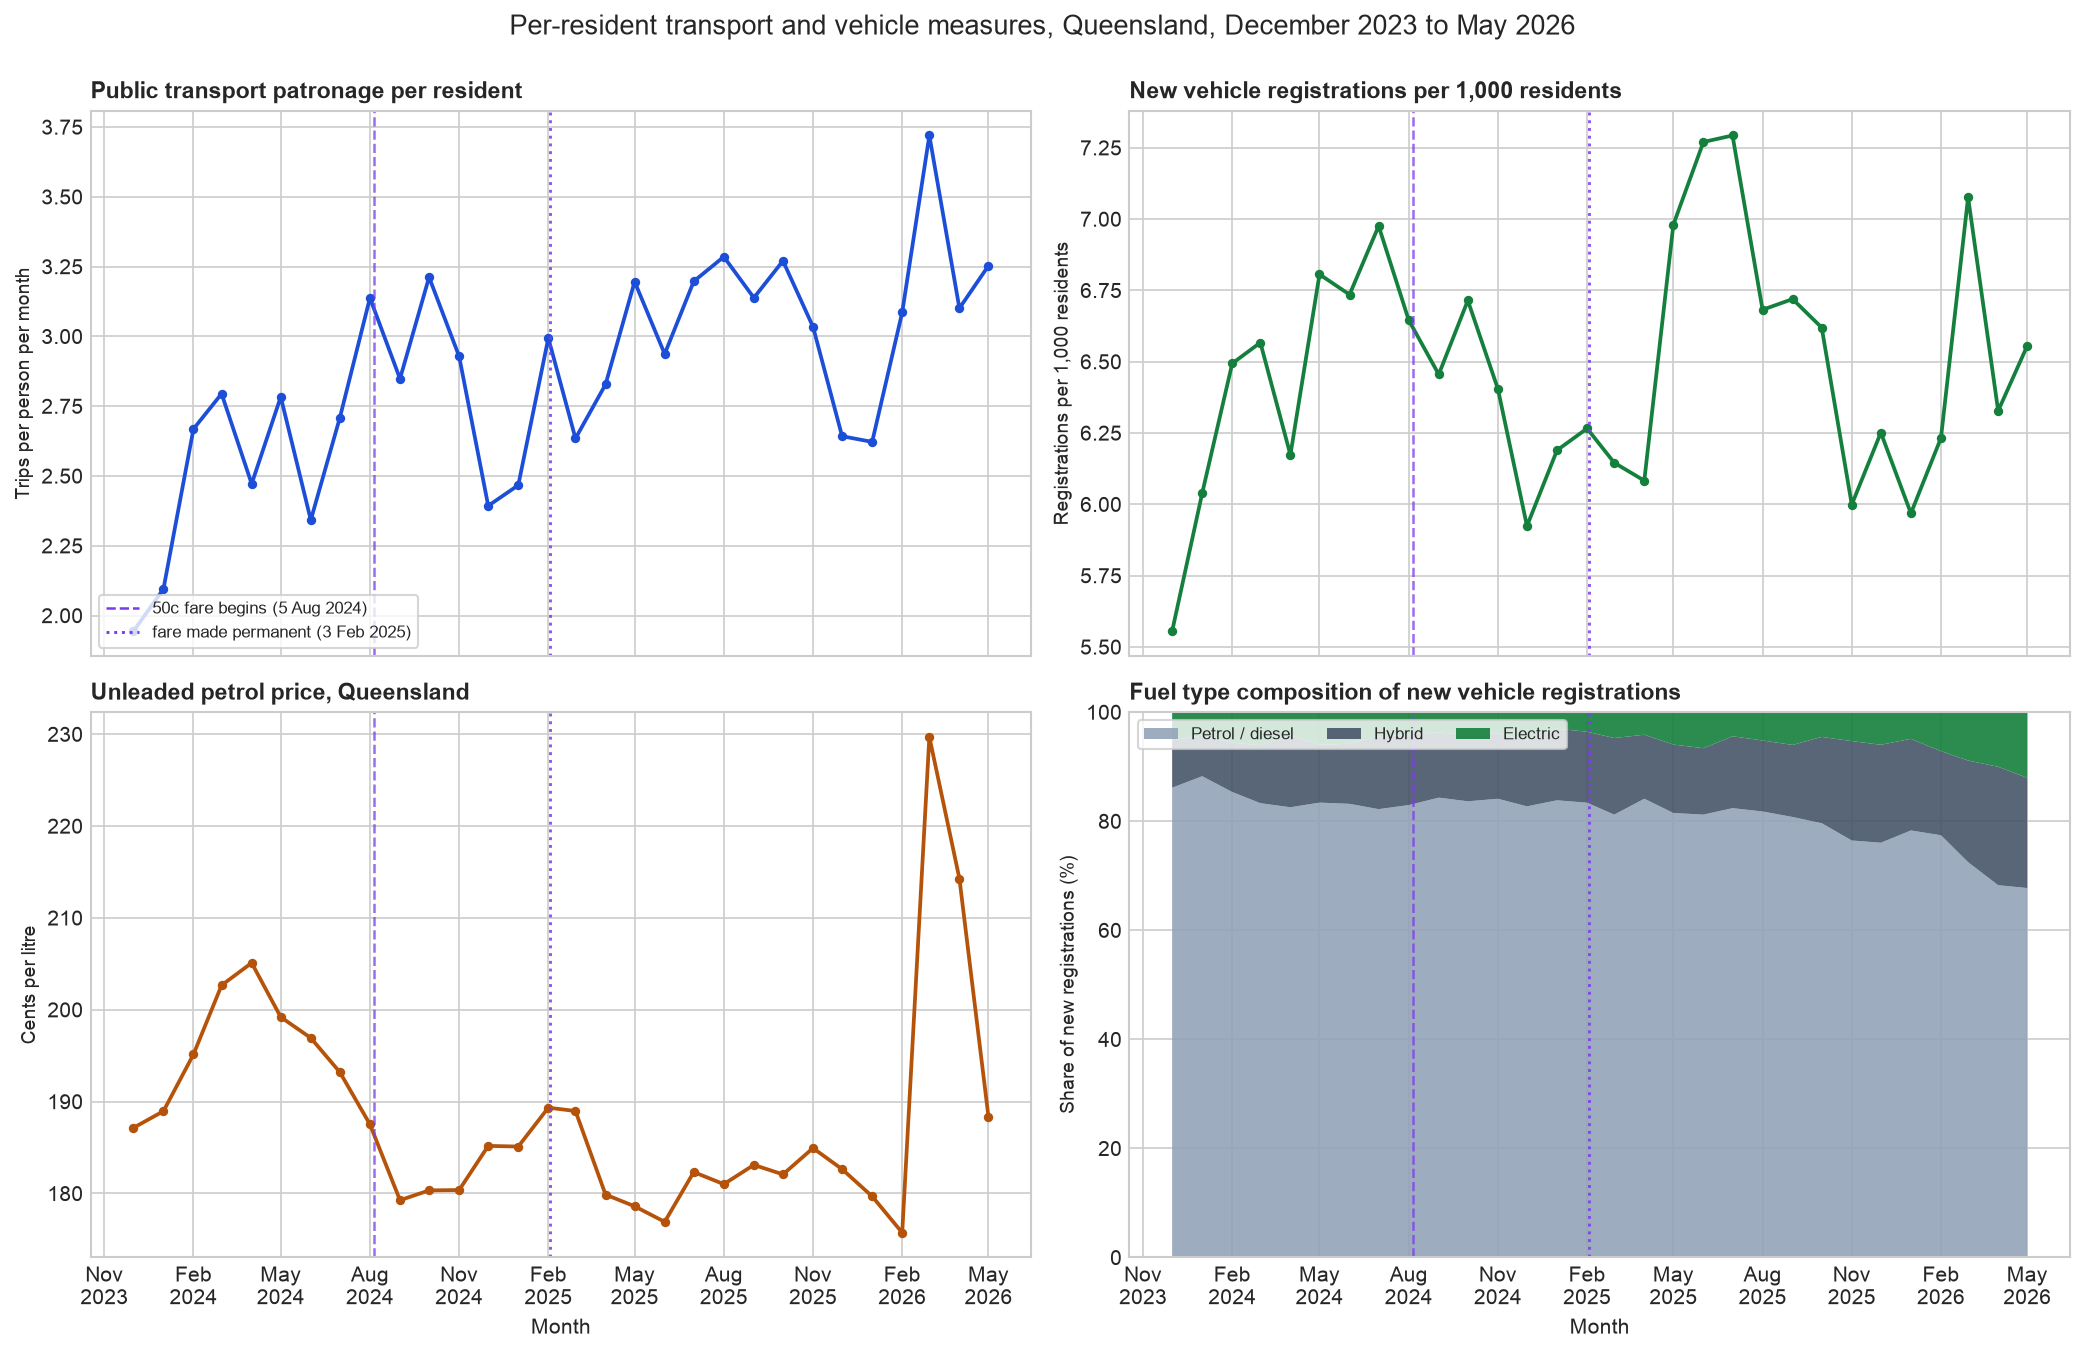

In [54]:
# Raw on the left, per resident on the right, same variable in the same colour,
# so the size of the population adjustment is visible rather than asserted.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
ax = axes.ravel()

# Counts are shown per resident. The fuel price is not a count, so it keeps its
# own units -- there is no defensible way to divide cents per litre by people.
panels = [
    (analysis['trips_per_resident'], 'Public transport patronage per resident',
     'Trips per person per month', C['patronage']),
    (analysis['registrations_per_1000'], 'New vehicle registrations per 1,000 residents',
     'Registrations per 1,000 residents', C['cars']),
    (analysis['ulp_cpl'], 'Unleaded petrol price, Queensland',
     'Cents per litre', C['fuel']),
]
for a, (series, title, ylab, colour) in zip(ax, panels):
    a.plot(series.index, series.values, color=colour, marker='o', ms=3.5, lw=1.8)
    a.set_title(title, loc='left', fontsize=11, fontweight='bold')
    a.set_ylabel(ylab, fontsize=9)
    a.axvline(FARE_TRIAL, **POLICY_KW)
    a.axvline(FARE_PERMANENT, **PERMANENT_KW)

# Fourth panel: what new registrations are made of. Categories must be mutually
# exclusive -- "Petrol And Electric" is a hybrid, and matching naively on
# 'petrol' would count it as both a petrol car and a hybrid. A share is a ratio
# of registrations to registrations, so population cancels and this is the one
# panel that needs no adjustment.
mix = reg_by_fuel.reindex(analysis.index).fillna(0)
CONVENTIONAL = {'petrol', 'diesel', 'gas', 'petrol and gas', 'diesel and gas'}
groups = {
    'Petrol / diesel': [c for c in mix.columns if c.strip().lower() in CONVENTIONAL],
    'Hybrid':          [c for c in mix.columns if 'and electric' in c.lower()],
    'Electric':        [c for c in mix.columns if c.strip().lower() == 'electric'],
}
share = pd.DataFrame({g: mix[cols].sum(axis=1) for g, cols in groups.items()})
share = share.div(share.sum(axis=1), axis=0) * 100

ax[3].stackplot(share.index, [share[g] for g in share.columns], labels=share.columns,
                colors=['#94a3b8', '#475569', C['cars']], alpha=0.9)
ax[3].set_title('Fuel type composition of new vehicle registrations',
                loc='left', fontsize=11, fontweight='bold')
ax[3].set_ylabel('Share of new registrations (%)', fontsize=9)
ax[3].set_ylim(0, 100)
ax[3].legend(loc='upper left', fontsize=8, ncol=3, frameon=True)
ax[3].axvline(FARE_TRIAL, **POLICY_KW)
ax[3].axvline(FARE_PERMANENT, **PERMANENT_KW)

# Label the two policy lines once, in the first panel's legend, rather than
# annotating all four.
axes[0, 0].legend(handles=[
    Line2D([], [], color=C['fare'], ls='--', lw=1.2, label='50c fare begins (5 Aug 2024)'),
    Line2D([], [], color=C['fare'], ls=':', lw=1.4, label='fare made permanent (3 Feb 2025)'),
], loc='lower left', fontsize=8, frameon=True)

for a in axes[-1]:
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    a.set_xlabel('Month')
fig.suptitle('Per-resident transport and vehicle measures, Queensland, December 2023 to May 2026',
             fontsize=13, y=0.997)
plt.tight_layout()
plt.show()

**Reading the shapes.** Counts are per resident throughout, and the shapes are what matter.
Patronage has a clear seasonal sawtooth and a visible step up after August 2024; dividing by
population lowers the line without flattening the step, which is the first sign that the step is
not simply the state growing. Registrations tell a different story, and the adjustment is not the
whole of it: the per-1,000-resident series is far more volatile than patronage, swinging between
roughly 107 and 131 on the index, and drifts up only slowly to end about a fifth above where it
started. Only about a fifth of that rise is population — dividing by residents takes off no more
than that — so car buying per person did increase over the window, just far less than patronage
did. The fuel price wanders in a band around $1.80–1.90/L and then spikes hard in early 2026. The
composition panel is the one that needs no adjustment at all — a share is already a ratio, so
dividing it by population would be counting the denominator twice.

**Two more views of the same window.** Indexing every series to the first month of the window
puts them on one axis, which answers a question four separate y-axes cannot: moved most,
relative to where it started. The heatmap does the opposite, keeping the levels and laying them
out as a month-by-year grid so the summer peaks line up vertically and the year-on-year step
after August 2024 reads across the rows.

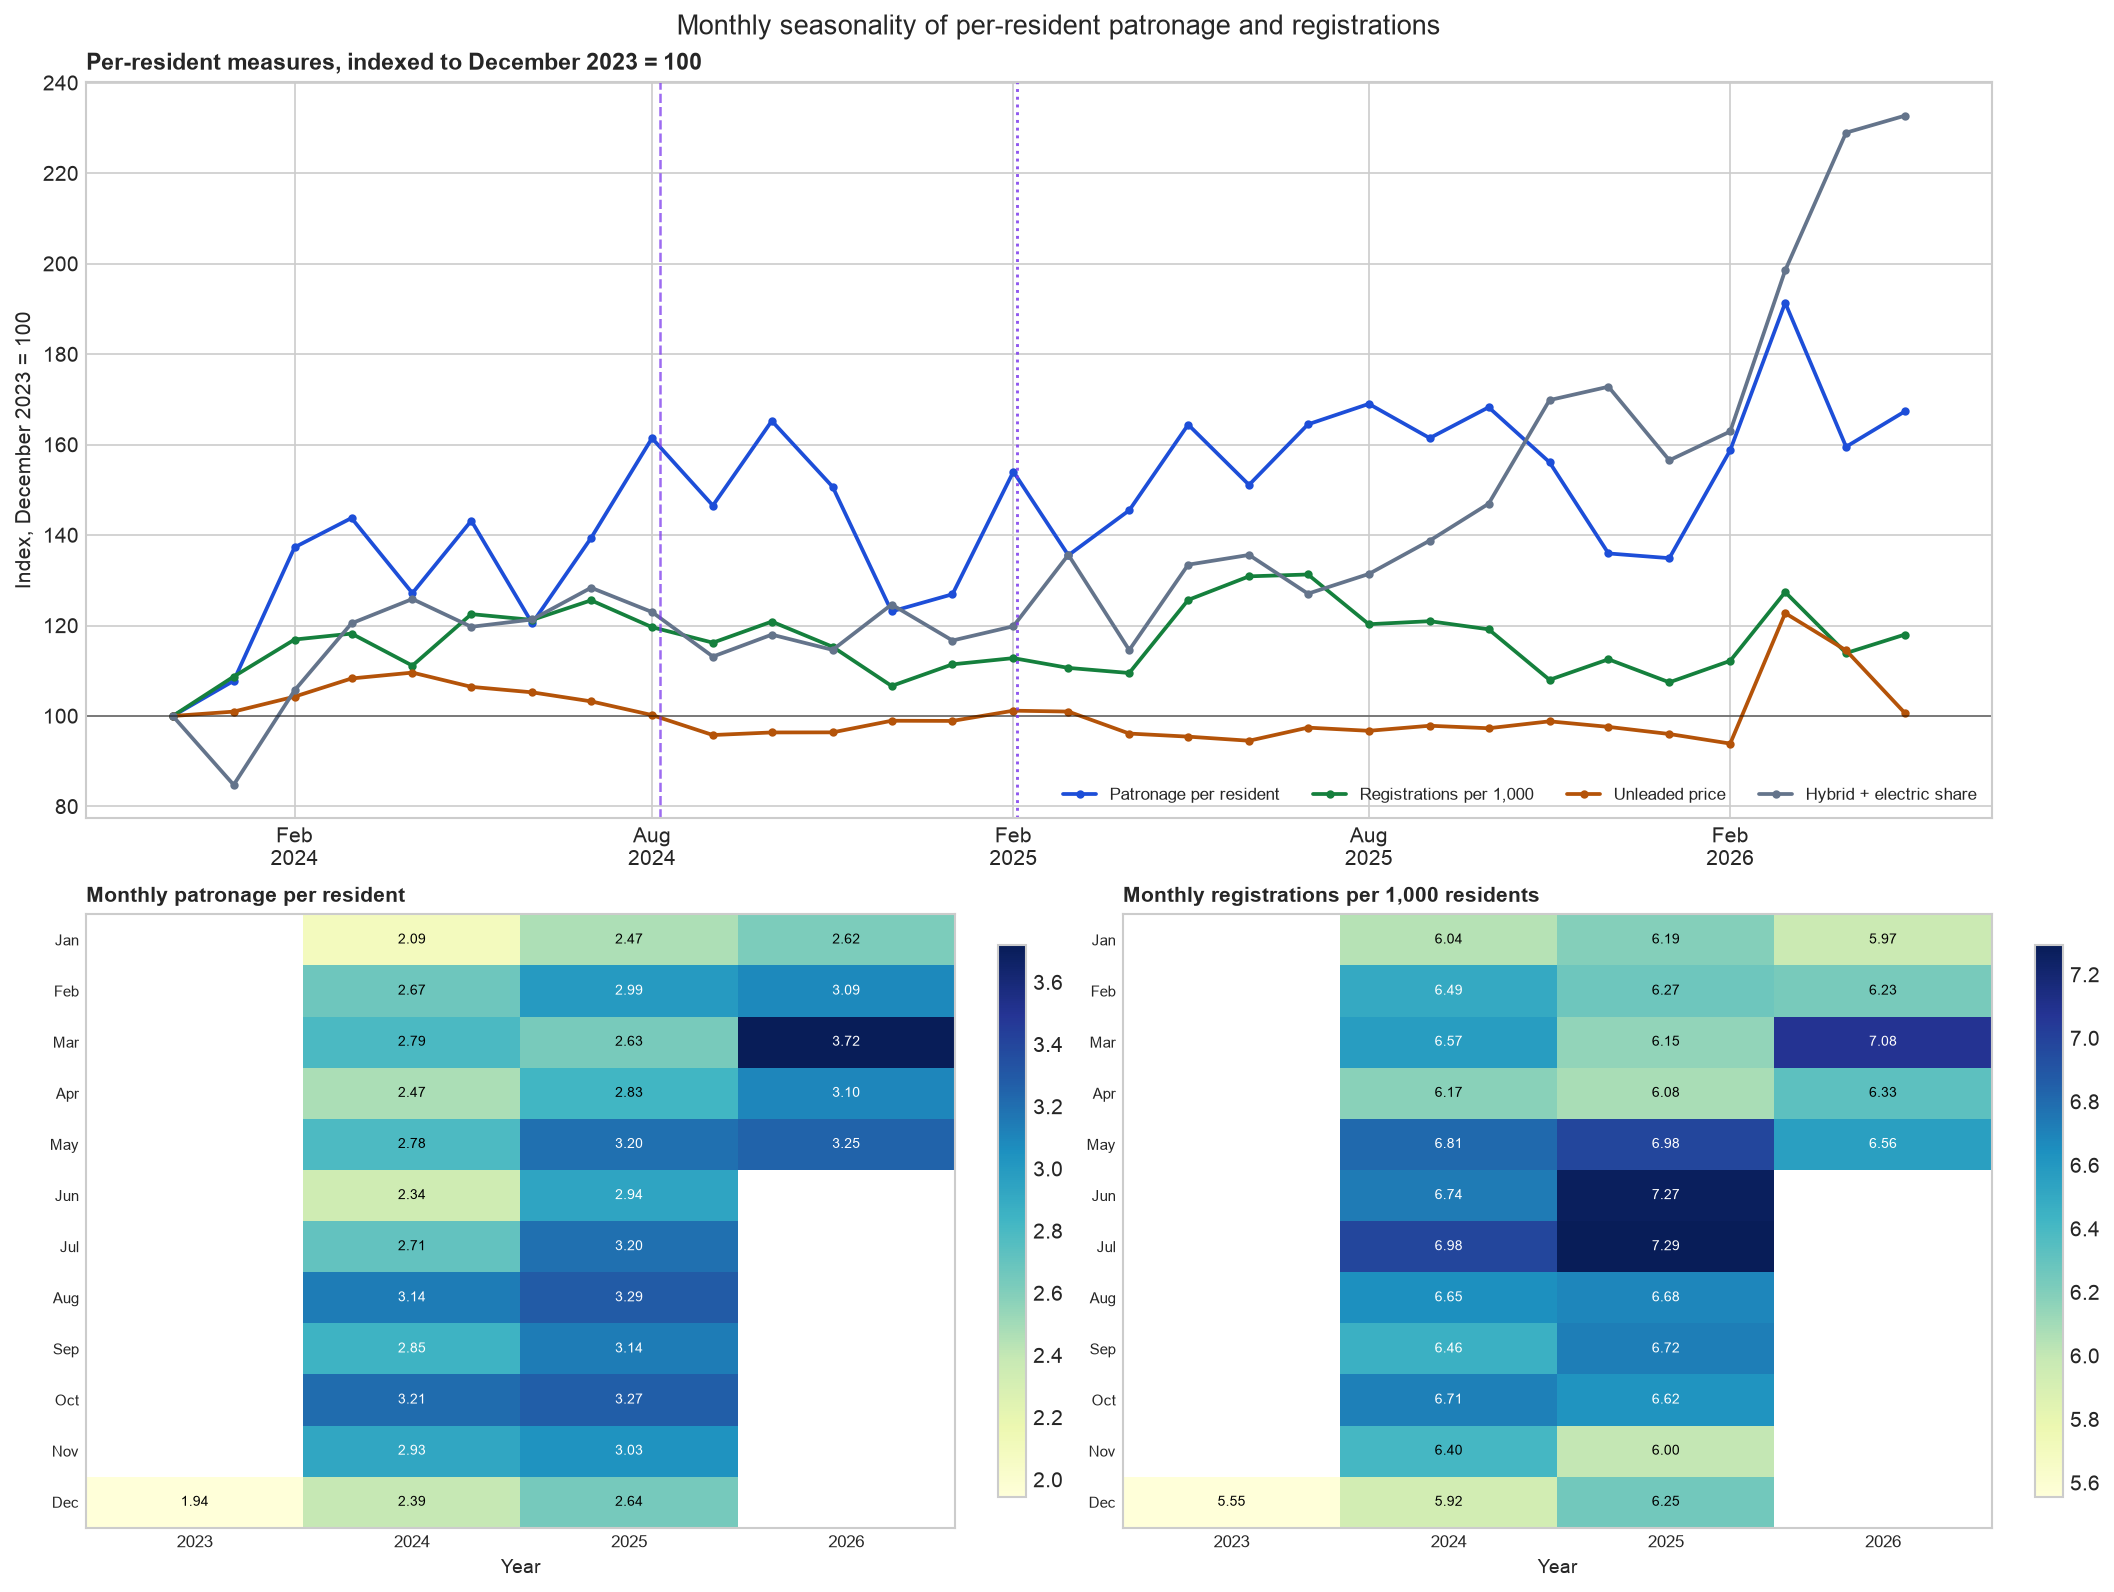

Index at the last month, Dec 2023 = 100:
Hybrid + electric share   232.70
Patronage per resident    167.40
Registrations per 1,000   118.00
Unleaded price            100.60

Queensland population on the same index: 104.4
Every count above has that growth already divided out, so what remains
cannot be explained by the state getting bigger.


In [55]:
# Everything rebased to Dec 2023 = 100. Counts enter per resident, so what is
# left is the movement that population growth does not account for. Population
# itself is printed underneath as the yardstick for how much was removed.
indexed = pd.DataFrame({
    'Patronage per resident': analysis['trips_per_resident'],
    'Registrations per 1,000': analysis['registrations_per_1000'],
    'Unleaded price': analysis['ulp_cpl'],
    'Hybrid + electric share': share['Hybrid'] + share['Electric'],
}).dropna()
indexed = indexed / indexed.iloc[0] * 100

fig = plt.figure(figsize=(14, 10.5), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

ax = fig.add_subplot(gs[0, :])
for col, colour in [('Patronage per resident', C['patronage']),
                    ('Registrations per 1,000', C['cars']),
                    ('Unleaded price', C['fuel']),
                    ('Hybrid + electric share', C['muted'])]:
    ax.plot(indexed.index, indexed[col], color=colour, marker='o', ms=3, lw=1.8, label=col)
ax.axhline(100, color='black', lw=0.8, alpha=0.5)
ax.axvline(FARE_TRIAL, **POLICY_KW)
ax.axvline(FARE_PERMANENT, **PERMANENT_KW)
ax.set_title('Per-resident measures, indexed to December 2023 = 100', loc='left',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Index, December 2023 = 100')
ax.legend(fontsize=8, ncol=4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))


def month_year(series):
    # Month rows by year columns -- the layout that makes seasonality visible.
    g = series.to_frame('v')
    g.index = g.index.rename(None)   # 'month' would collide with the column below
    g['year'] = g.index.year
    g['month'] = g.index.month
    return g.pivot_table(index='month', columns='year', values='v').reindex(range(1, 13))


# Seasonality of both count series, each per resident. They are in different
# units -- trips against registrations per 1,000 -- so each grid carries its own
# colour scale rather than sharing one that would invite a false comparison.
for k, (series, label, fmt) in enumerate([
        (analysis['trips_per_resident'], 'Monthly patronage per resident', '{:.2f}'),
        (analysis['registrations_per_1000'], 'Monthly registrations per 1,000 residents', '{:.2f}')]):
    grid = month_year(series)
    a = fig.add_subplot(gs[1, k])
    im = a.imshow(grid.values, cmap='YlGnBu', aspect='auto')
    a.set_xticks(range(len(grid.columns)), [str(y) for y in grid.columns], fontsize=8)
    a.set_yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=7)
    cut = (np.nanmin(grid.values) + np.nanmax(grid.values)) / 2
    for r in range(12):
        for c in range(len(grid.columns)):
            v = grid.values[r, c]
            if not np.isnan(v):
                a.text(c, r, fmt.format(v), ha='center', va='center', fontsize=6.5,
                       color='white' if v > cut else 'black')
    a.set_title(label, loc='left', fontsize=10, fontweight='bold')
    a.set_xlabel('Year', fontsize=9)
    # The whitegrid style draws lines at every tick, which on an imshow land on
    # the centre of each cell and cut it in half.
    a.grid(False)
    fig.colorbar(im, ax=a, shrink=0.9)
fig.suptitle('Monthly seasonality of per-resident patronage and registrations', fontsize=13)
plt.show()

pop_index = 100 * pop_monthly.iloc[-1] / pop_monthly.iloc[0]
print('Index at the last month, Dec 2023 = 100:')
print(indexed.iloc[-1].round(1).sort_values(ascending=False).to_string())
print()
print(f'Queensland population on the same index: {pop_index:.1f}')
print('Every count above has that growth already divided out, so what remains')
print('cannot be explained by the state getting bigger.')

**Reading the picture.** Three series have risen and one has gone nowhere. The hybrid-plus-
electric share more than doubles, from 13.9% of new registrations to 32.3%; trips per resident
end two-thirds above their December 2023 level, at 167 on the index; registrations per 1,000
residents are up by about a fifth, at 118; and the unleaded price ends at 101, close to where it
started, despite swinging widely in between. That divergence is the argument of the whole notebook in
one chart — a series that climbs steadily across three years cannot be responding to a price
that returns to its starting point. Note what the per-resident counts have already removed.
Queensland's population grew by about 4% over the window, so the raw trip and registration
lines would both have been steeper; every count in this figure has that growth divided out
before it is drawn, and what remains cannot be explained by the state getting bigger. The two
heatmaps show what the year-on-year method corrects for: every year peaks in the same months,
so a before-and-after average taken over a mostly-summer pre-window would have compared the
seasons rather than the policy. The second grid is the more sharply seasonal of the two,
because car buying swings harder across the year than public transport use does.

**4.2 The correlation trap.** Every one of these series trends or cycles over 30 months, so a
correlation between **levels** mostly measures the fact that they all exist in the same window.
The honest comparison is between **year-on-year changes**, which removes the shared seasonal
cycle and the common trend.

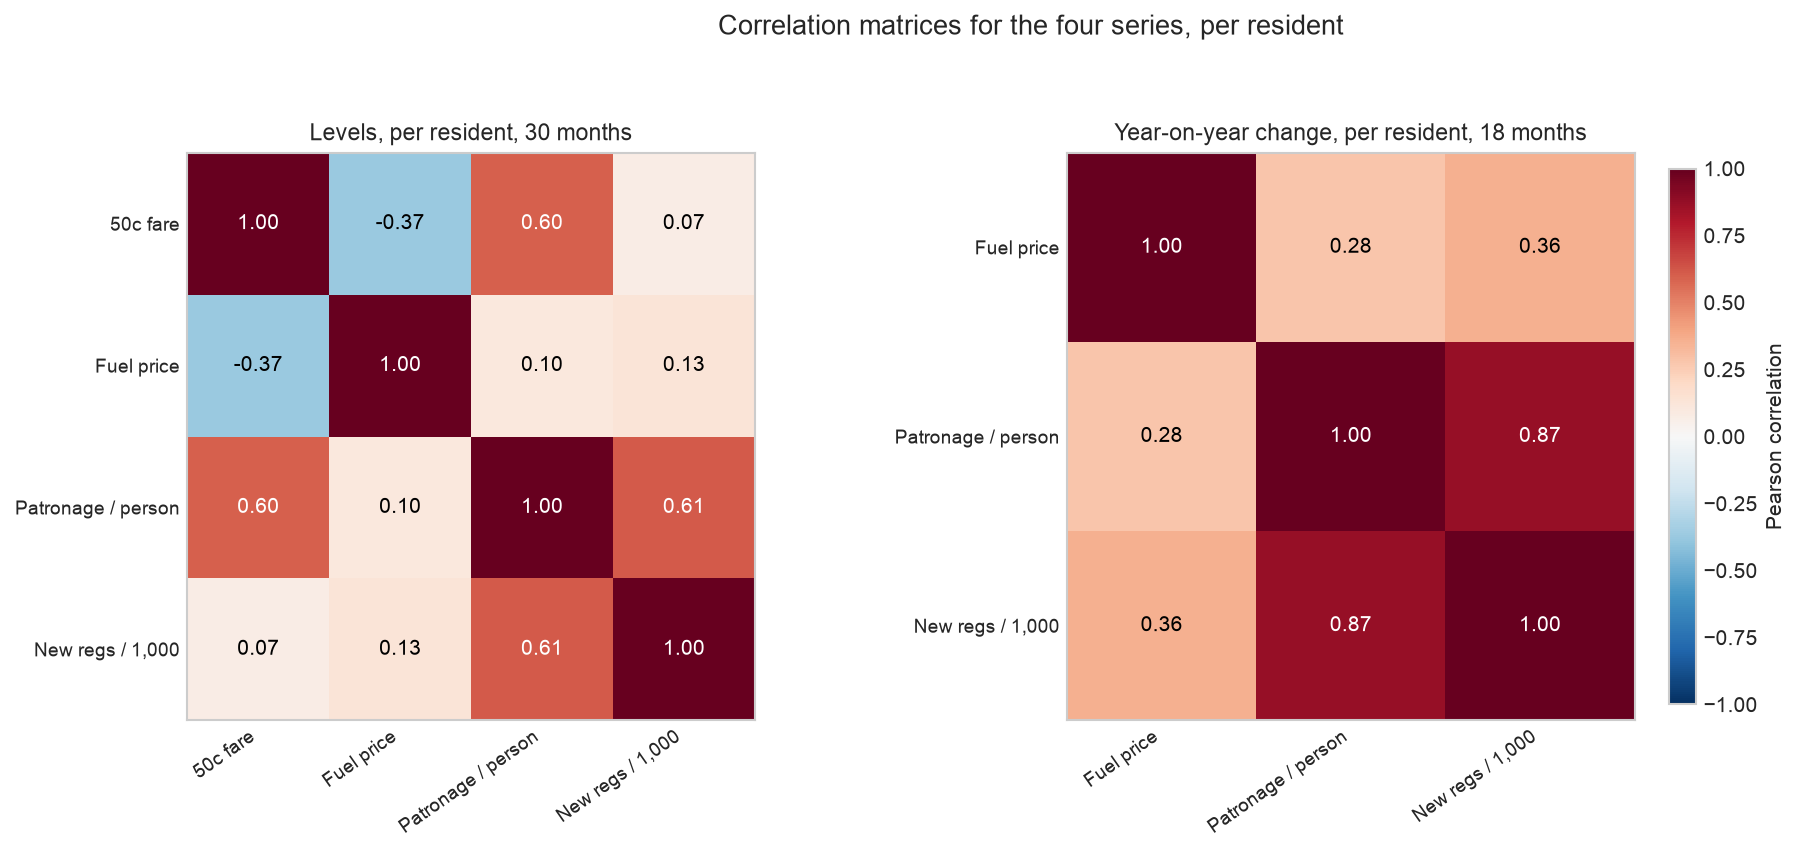

Levels, per resident:
                    50c fare  Fuel price  Patronage / person  New regs / 1,000
50c fare                1.00       -0.37                0.60              0.07
Fuel price             -0.37        1.00                0.10              0.13
Patronage / person      0.60        0.10                1.00              0.61
New regs / 1,000        0.07        0.13                0.61              1.00

Year-on-year %, per resident:
                    Fuel price  Patronage / person  New regs / 1,000
Fuel price                1.00                0.28              0.36
Patronage / person        0.28                1.00              0.87
New regs / 1,000          0.36                0.87              1.00

Strongest year-on-year relationships, per resident:
Patronage / person  ~  New regs / 1,000   0.87
Fuel price  ~  New regs / 1,000           0.36
Fuel price  ~  Patronage / person         0.28


In [56]:
# Counts per resident. The fuel price and the fare dummy are not counts, so they
# stay in their own units -- dividing a price, or a 0/1 flag, by population would
# be meaningless.
HEAD = {'fare_50c': '50c fare', 'ulp_cpl': 'Fuel price',
        'trips_per_resident': 'Patronage / person',
        'registrations_per_1000': 'New regs / 1,000'}

lev_head = analysis[list(HEAD)].rename(columns=HEAD)

# Year-on-year change: same month, one year apart. Costs 12 observations, which
# has a consequence worth noting -- every surviving month is already post-policy,
# so the fare dummy is constant here and drops out. It cannot be correlated with
# anything in this frame; that is a limit of the design, not a missing number.
yoy_head = (analysis[['ulp_cpl', 'trips_per_resident', 'registrations_per_1000']]
            .pct_change(12, fill_method=None) * 100).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
fig.subplots_adjust(wspace=0.55)
for ax, m, title in [
        (axes[0], lev_head.corr(), f'Levels, per resident, {len(lev_head)} months'),
        (axes[1], yoy_head.rename(columns=HEAD).corr(),
         f'Year-on-year change, per resident, {len(yoy_head)} months')]:
    im = ax.imshow(m.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(m)), m.columns, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(m)), m.index, fontsize=9)
    ax.set_title(title, fontsize=11)
    for a in range(len(m)):
        for b in range(len(m)):
            v = m.values[a, b]
            ax.text(b, a, f'{v:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if abs(v) > 0.55 else 'black')
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, label='Pearson correlation')
fig.suptitle('Correlation matrices for the four series, per resident', fontsize=13)
plt.show()

print('Levels, per resident:')
print(lev_head.corr().round(2).to_string())
print()
print('Year-on-year %, per resident:')
corr_yoy_head = yoy_head.rename(columns=HEAD).corr()
print(corr_yoy_head.round(2).to_string())
print()
print('Strongest year-on-year relationships, per resident:')
pairs = (corr_yoy_head.where(~np.eye(len(corr_yoy_head), dtype=bool))
         .stack().dropna().sort_values(ascending=False))
seen, out = set(), []
for (a, b), v in pairs.items():
    key = frozenset((a, b))
    if key not in seen:
        seen.add(key)
        out.append((f'{a}  ~  {b}', v))
print(pd.Series(dict(out)).head(5).round(2).to_string())

**Read the numbers before the colour.** Everything here is counted per resident. The raw
figures are quoted rather than drawn, because they are the comparison the adjustment has to
answer for. On raw levels the picture is mixed rather than uniformly strong: patronage moves
with new registrations at 0.69 and with the fare dummy at 0.63, while the fuel price barely
registers against either (0.10 against patronage, 0.11 against registrations). Recounting per
resident lowers those exactly where it should. The fare dummy against registrations falls from
0.21 to 0.07, and patronage against registrations from 0.69 to 0.61, because part of what those
pairs shared was simply a state that kept growing. The fare dummy against patronage barely moves
at all, 0.63 to 0.60, which is informative in its own right: whatever that correlation is
measuring, it is not mainly population.

The more interesting result is where the adjustment does nothing. The year-on-year matrix is
essentially the same whichever way the counts are expressed — 0.87 for patronage against
registrations on raw trips and 0.87 per resident, 0.35 against 0.36 for fuel — because comparing
the same month a year earlier has already removed the population trend that the denominator would
remove. The two corrections are largely redundant, and noticing that is useful: it says the
year-on-year frame was the population-clean comparison all along, and the per-resident counts
are a check on it rather than a replacement.

Note finally what is missing from the year-on-year matrix. The fare dummy appears in the levels
panel but cannot appear here, because a frame reaching back twelve months survives only in months
that are already post-policy, where the dummy is constant. That is a limit of the design, not a
missing number, and it is why the fare's effect has to be read off the before/after comparison in
§4.3 rather than off a correlation.

**4.3 RQ2 — did the 50-cent fare lift patronage?** With only eight months before the change, a
simple before/after average would be swamped by seasonality — the pre-window is almost entirely
summer. So the comparison is **same month, one year earlier**: March 2025 against March 2024,
and so on. That removes the seasonal shape and leaves the change over the year.

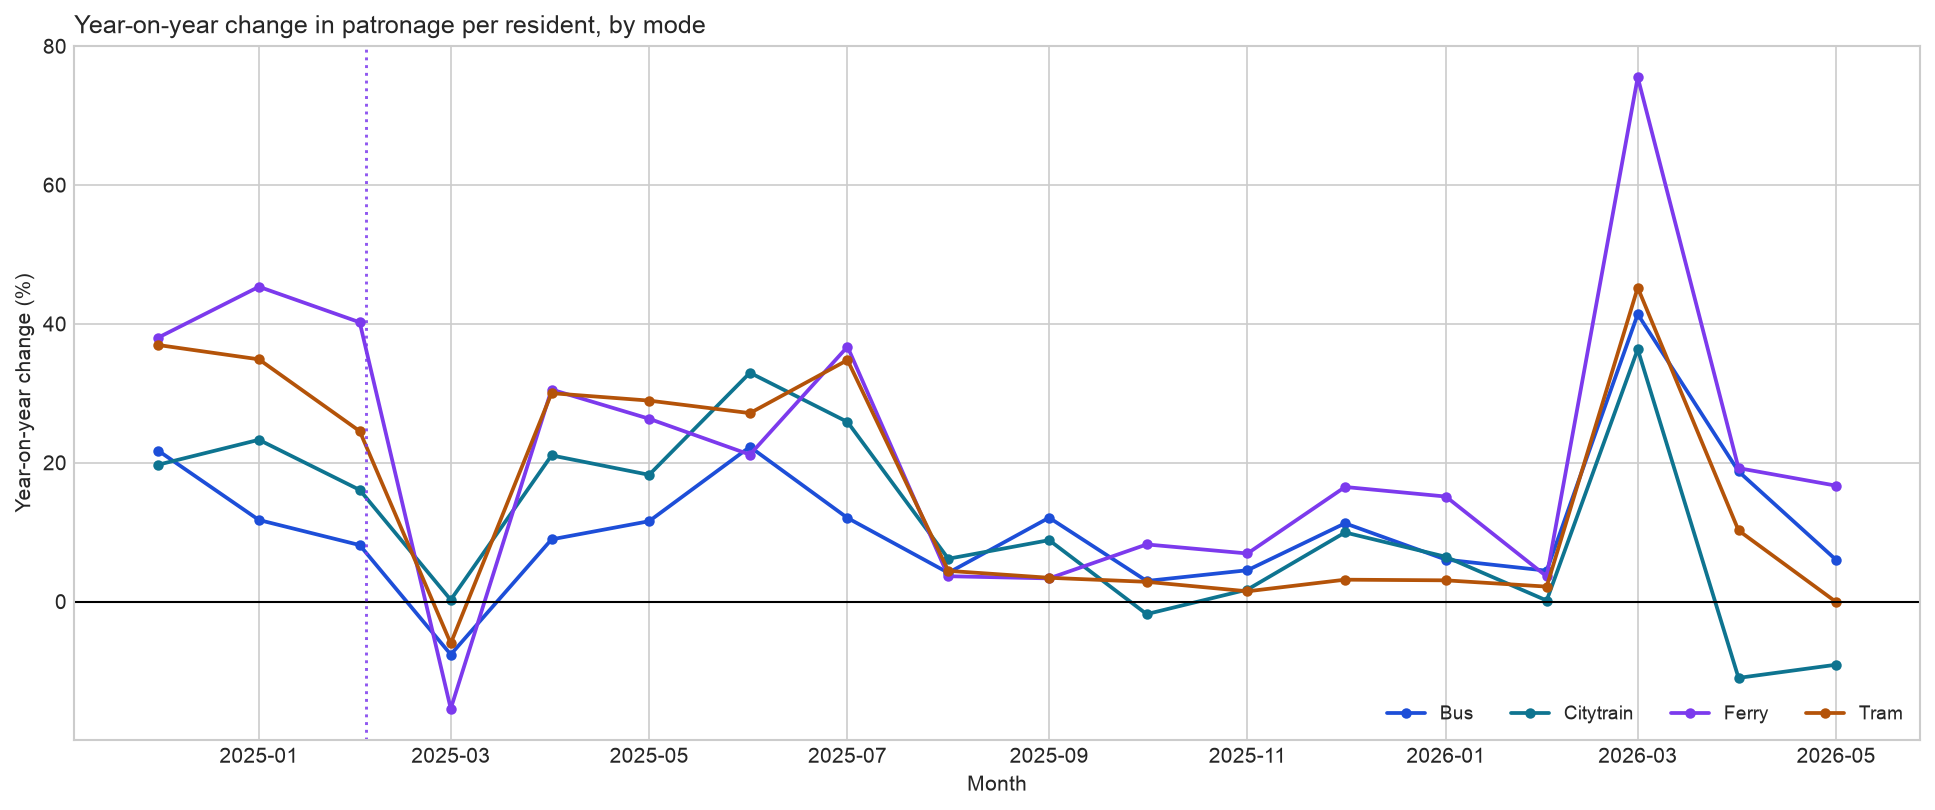

Mean year-on-year change in trips per resident after the fare cut:
mode
Ferry       21.80
Tram        16.00
Citytrain   11.40
Bus         11.10

The same figures on raw trips, for comparison:
mode
Ferry       23.90
Tram        18.00
Citytrain   13.30
Bus         13.10

Population growth lifts every mode by about 2.0 points, which is the part of the raw growth no fare bought.

Two periods, to test whether the increase persisted (per resident):
           first policy year (Sep24-Aug25)  since Sep 2025
mode                                                      
Bus                                  10.30           11.90
Citytrain                            18.20            4.60
Ferry                                25.20           18.30
Tram                                 24.00            7.90


In [57]:
yoy_mode = trips_by_mode.pct_change(12, fill_method=None) * 100
# Start from the first fully-treated month, so the transition month is not counted.
yoy_mode = yoy_mode.loc[yoy_mode.index >= FARE_FIRST_FULL_MONTH].dropna(how='all')

# The same growth rates per resident. A mode that grows 13% while the population
# it draws from grows 2% has grown 11% in the only sense a passenger would
# recognise.
pop_aligned = pop_monthly.reindex(trips_by_mode.index)
yoy_mode_rate = (trips_by_mode.div(pop_aligned, axis=0)
                 .pct_change(12, fill_method=None) * 100)
yoy_mode_rate = (yoy_mode_rate.loc[yoy_mode_rate.index >= FARE_FIRST_FULL_MONTH]
                 .dropna(how='all'))

mode_colours = {'Bus': '#1d4ed8', 'Citytrain': '#0e7490', 'Ferry': '#7c3aed', 'Tram': '#b45309'}
fig, ax = plt.subplots(figsize=(13, 5.5))
for mode in yoy_mode_rate.columns:
    ax.plot(yoy_mode_rate.index, yoy_mode_rate[mode], marker='o', ms=4, lw=1.8,
            color=mode_colours.get(mode, C['muted']), label=mode)
ax.axhline(0, color='black', lw=1)
ax.axvline(FARE_PERMANENT, **PERMANENT_KW)
ax.set_title('Year-on-year change in patronage per resident, by mode',
             loc='left')
ax.set_ylabel('Year-on-year change (%)')
ax.set_xlabel('Month')
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

print('Mean year-on-year change in trips per resident after the fare cut:')
print(yoy_mode_rate.mean().sort_values(ascending=False).round(1).to_string())
print()
print('The same figures on raw trips, for comparison:')
print(yoy_mode.mean().sort_values(ascending=False).round(1).to_string())
print()
print(f'Population growth lifts every mode by about '
      f'{(yoy_mode.mean() - yoy_mode_rate.mean()).mean():.1f} points, which is the part '
      f'of the raw growth no fare bought.')
print()
print('Two periods, to test whether the increase persisted (per resident):')
first_year = yoy_mode_rate.loc[:'2025-08-31'].mean()
second_year = yoy_mode_rate.loc['2025-09-01':].mean()
print(pd.DataFrame({'first policy year (Sep24-Aug25)': first_year,
                    'since Sep 2025': second_year}).round(1).to_string())

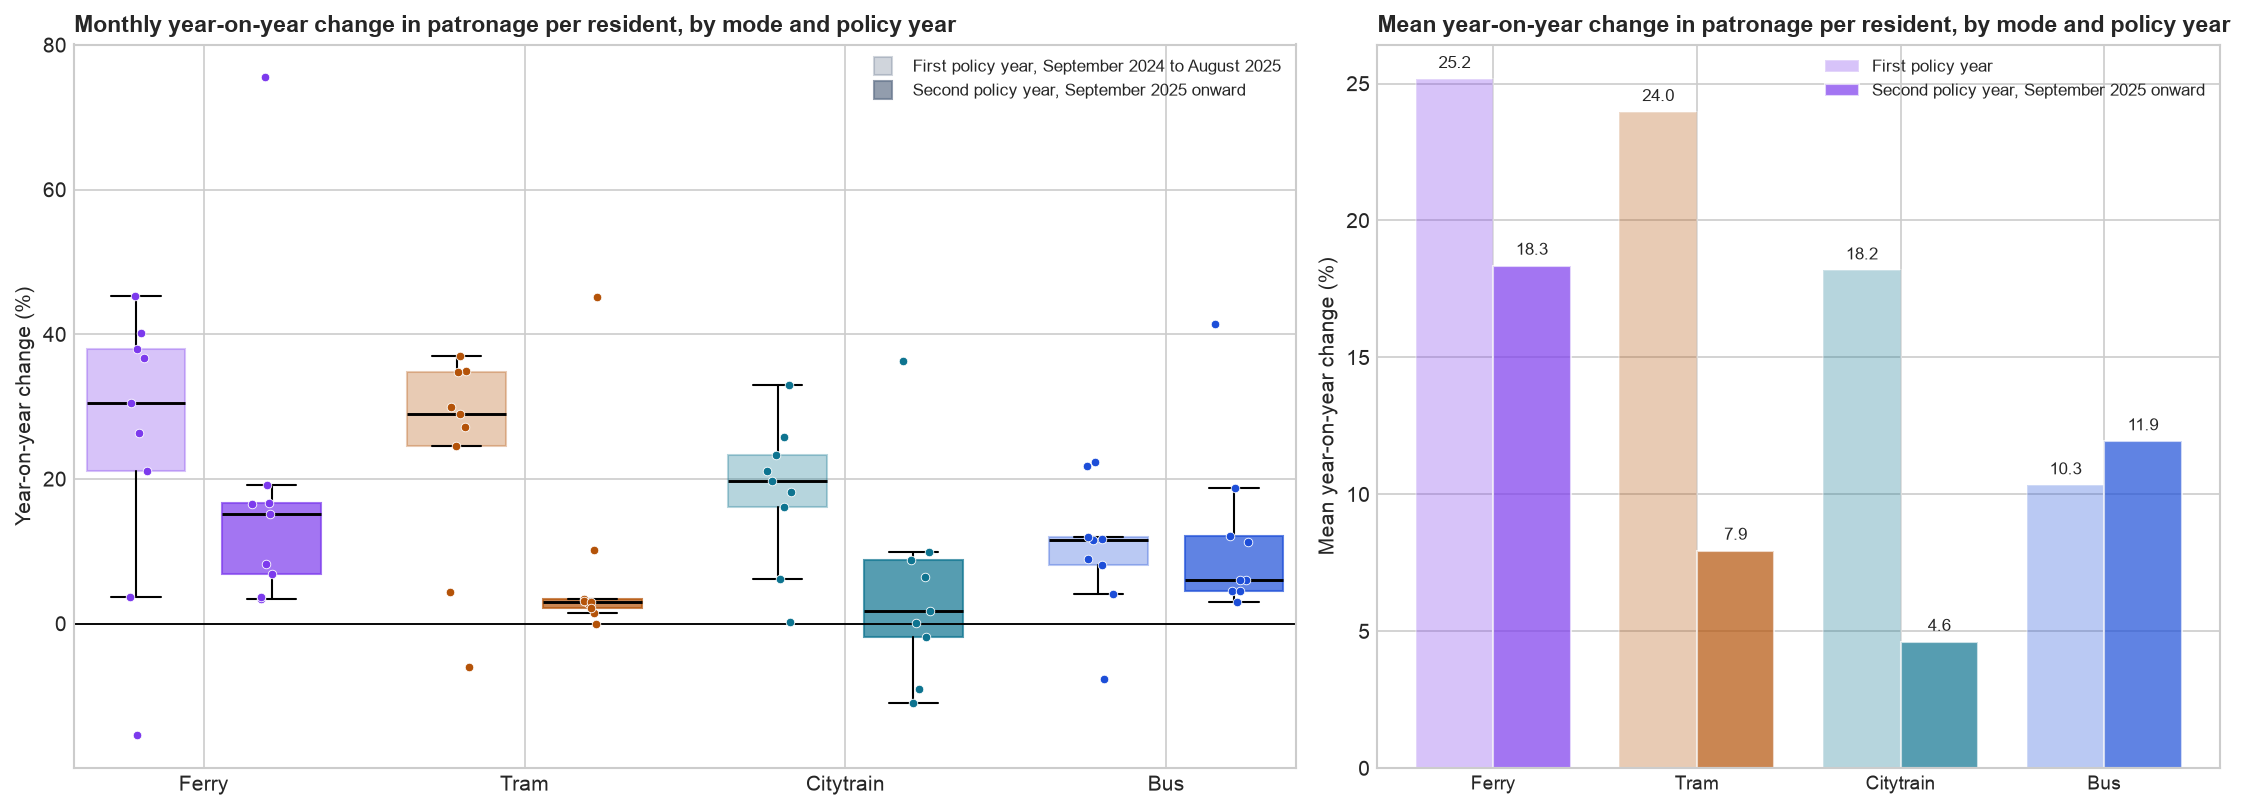

In [58]:
# The same two periods as the table above, drawn. With only 12 and 9 monthly
# observations a mean on its own hides how variable the months are, so every box
# is overlaid with its own points rather than standing alone.
mode_order = yoy_mode_rate.mean().sort_values(ascending=False).index.tolist()
mode_colours = {'Bus': '#1d4ed8', 'Citytrain': '#0e7490', 'Ferry': '#7c3aed', 'Tram': '#b45309'}
rate_parts = (yoy_mode_rate.loc[:'2025-08-31'], yoy_mode_rate.loc['2025-09-01':])
rng = np.random.default_rng(0)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5.5),
                              gridspec_kw={'width_ratios': [1.45, 1]})
ticks, labels = [], []
for i, mode in enumerate(mode_order):
    colour = mode_colours.get(mode, C['muted'])
    for j, part in enumerate(rate_parts):
        pos = i * 2.6 + j * 1.1 + 1
        pts = part[mode].dropna()
        bp = ax.boxplot([pts], positions=[pos], widths=0.8, patch_artist=True,
                        showfliers=False, medianprops=dict(color='black', lw=1.4))
        bp['boxes'][0].set(facecolor=colour, edgecolor=colour, alpha=0.30 if j == 0 else 0.70)
        ax.scatter(rng.normal(pos, 0.07, len(pts)), pts, s=17, color=colour,
                   edgecolor='white', linewidth=0.4, zorder=3)
    ticks.append(i * 2.6 + 1.55)
    labels.append(mode)
ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(ticks, labels)
ax.set_ylabel('Year-on-year change (%)')
ax.set_title('Monthly year-on-year change in patronage per resident, by mode and policy year', loc='left',
             fontsize=11, fontweight='bold')
ax.legend(handles=[
    Line2D([], [], marker='s', ls='', ms=9, mfc=C['muted'], mec=C['muted'], alpha=0.30,
           label='First policy year, September 2024 to August 2025'),
    Line2D([], [], marker='s', ls='', ms=9, mfc=C['muted'], mec=C['muted'], alpha=0.70,
           label='Second policy year, September 2025 onward'),
], fontsize=8, loc='upper right')

periods = pd.DataFrame({'first': rate_parts[0].mean(),
                        'second': rate_parts[1].mean()}).loc[mode_order]
x = np.arange(len(mode_order))
w = 0.38
colours = [mode_colours.get(m, C['muted']) for m in mode_order]
ax2.bar(x - w / 2, periods['first'], w, color=colours, alpha=0.30, edgecolor='white',
        label='First policy year')
ax2.bar(x + w / 2, periods['second'], w, color=colours, alpha=0.70, edgecolor='white',
        label='Second policy year, September 2025 onward')
for xi, (a, b) in enumerate(zip(periods['first'], periods['second'])):
    ax2.text(xi - w / 2, a + 0.4, f'{a:.1f}', ha='center', fontsize=8)
    ax2.text(xi + w / 2, b + 0.4, f'{b:.1f}', ha='center', fontsize=8)
ax2.axhline(0, color='black', lw=0.9)
ax2.set_xticks(x, mode_order, fontsize=9)
ax2.set_ylabel('Mean year-on-year change (%)')
ax2.set_title('Mean year-on-year change in patronage per resident, by mode and policy year', loc='left', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the persistence.** Bus is the only mode whose second period is at least as strong as
its first, and even there the two means sit close together. Ferry keeps a large gain but gives
back roughly a quarter of it. Citytrain and Tram are the clear decay cases: both post first-year
means above 18% and fall back to single digits afterwards, which is more consistent with a
novelty response than with a durable change in how people commute. The spread matters as much as
the means — where the monthly points scatter widely, any single month would tell you very little,
which is why the points are drawn rather than hidden behind the box.

These are per-resident figures, and that is what makes the comparison honest rather than
flattering. On raw trips the same numbers run about two points higher across the board, which is
population growth being credited to the fare. Subtracting it does not reorder the modes, but it
does sharpen the decay, because taking the same constant off both years widens the ratio between
them: Citytrain's fall from 18.2% to 4.6% is a steeper collapse than the raw 20.3% to 6.3%
suggested. Bus is the one mode still above zero a year later on either reading.

**Adjusting for population.** Queensland added residents throughout this window, and more
residents means more trips even if not one person changes their behaviour. Raw patronage growth
therefore hands the fare credit for something demography did. The honest comparison puts three
things side by side: the change in trips, the change in population, and the change in trips
*per resident* — which is the part a fare actually has to explain.

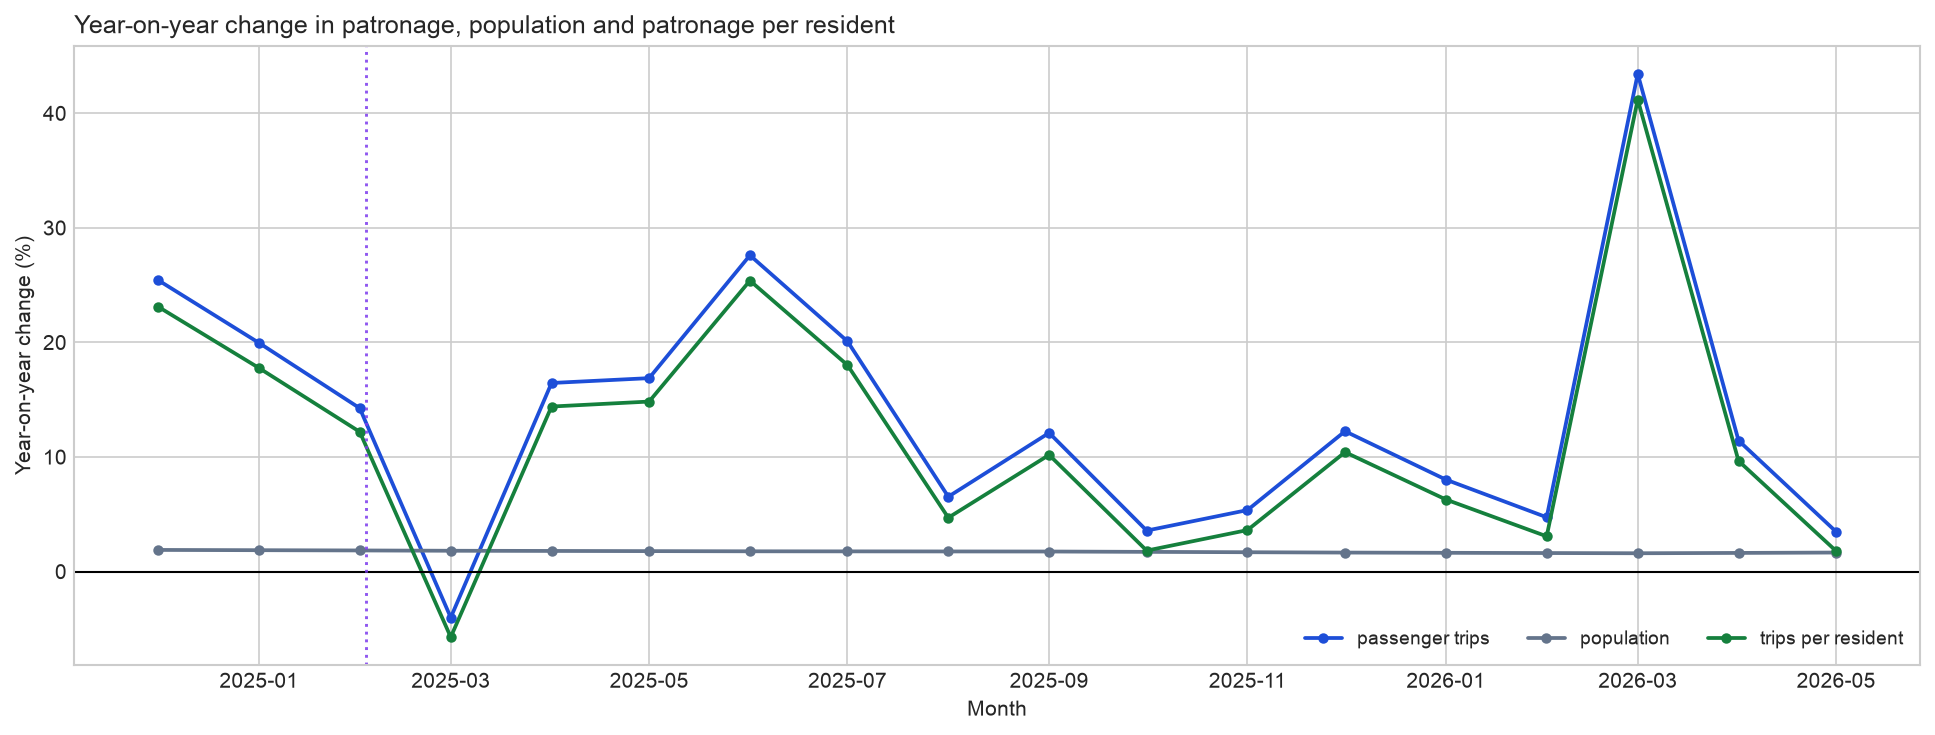

Mean year-on-year change after the fare cut, all modes together:
passenger trips      13.80
population            1.70
trips per resident   11.80

Population growth accounts for 1.7 of the 13.8 percentage-point rise in trips, about 13% of it.
The remaining 11.8% is the part the fare would have to explain.


In [59]:
# Same-month-year-earlier change, for the three quantities. Population is the
# denominator, so a year-on-year population change of +1.7% mechanically lifts
# raw patronage by about that much without anyone travelling more.
yoy_trips_all = trips_total.pct_change(12, fill_method=None) * 100
yoy_pop_all = pop_monthly.pct_change(12, fill_method=None) * 100
yoy_rate_all = trips_per_resident.pct_change(12, fill_method=None) * 100

decomp = pd.DataFrame({
    'passenger trips': yoy_trips_all,
    'population': yoy_pop_all,
    'trips per resident': yoy_rate_all,
}).dropna()
after = decomp.loc[FARE_FIRST_FULL_MONTH:]

fig, ax = plt.subplots(figsize=(13, 5))
for col, colour in [('passenger trips', C['patronage']), ('population', C['muted']),
                    ('trips per resident', C['cars'])]:
    ax.plot(after.index, after[col], marker='o', ms=4, lw=1.8, color=colour, label=col)
ax.axhline(0, color='black', lw=1)
ax.axvline(FARE_PERMANENT, **PERMANENT_KW)
ax.set_ylabel('Year-on-year change (%)')
ax.set_xlabel('Month')
ax.set_title('Year-on-year change in patronage, population and patronage per resident', loc='left')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

print('Mean year-on-year change after the fare cut, all modes together:')
print(after.mean().round(1).to_string())
print()
print(f'Population growth accounts for {after["population"].mean():.1f} of the '
      f'{after["passenger trips"].mean():.1f} percentage-point rise in trips, '
      f'about {100 * after["population"].mean() / after["passenger trips"].mean():.0f}% of it.')
print(f'The remaining {after["trips per resident"].mean():.1f}% is the part the fare would '
      f'have to explain.')

**What to look for.** If the fare cut lifted patronage, points should sit consistently above
zero after August 2024 and every mode should move the same way — a fare cut applies to all four
at once, so a mode that does *not* respond is informative. Two traps are visible in this chart.
The March 2025 dip across Ferry and Bus lines up with **Cyclone Alfred**, which shut down
Southeast Queensland services, and that matters twice over because the *next* March is compared
against it — the huge March 2026 spike is largely a depressed-base artefact, not a sudden surge
in travel. Separately, the early-2026 fuel spike lands in the same period as the highest
patronage readings, so the two levers are partly confounded at the end of the window.

To see the fare effect cleanly, read the right-hand half of the chart. From September 2025 the
comparison is policy-year against policy-year, so the lines show organic growth with no fare step
in the base: Bus holds up at about +11% per resident, and the other modes settle back after their
first-year jump. Every rate here is per resident, so the two points or so by which each mode sits
below its raw counterpart is population growth, and not the fare.

In [60]:
# The naive pre/post gap, shown only to demonstrate how misleading it is.
# The transition month is excluded from both sides.
mode_change = pd.DataFrame({
    'mean pre (Dec23-Jul24)': pre_m[trips_by_mode.columns].mean(),
    'mean post (Sep24-May26)': post_m[trips_by_mode.columns].mean(),
})
mode_change['change (%)'] = (mode_change.iloc[:, 1] / mode_change.iloc[:, 0] - 1) * 100
print(mode_change.round(0).to_string())
print()
print('But this gap is NOT a fare effect: the pre-window is Dec-Jul only, so it compares')
print('part of one summer with a full 21-month period. The year-on-year chart above is')
print('the honest version.')

           mean pre (Dec23-Jul24)  mean post (Sep24-May26)  change (%)
Bus                  8,709,279.00            10,495,876.00       21.00
Citytrain            3,644,357.00             4,584,693.00       26.00
Ferry                  479,126.00               672,766.00       40.00
Tram                   914,353.00             1,226,753.00       34.00

But this gap is NOT a fare effect: the pre-window is Dec-Jul only, so it compares
part of one summer with a full 21-month period. The year-on-year chart above is
the honest version.


**4.4 RQ3 and RQ4 — does the fuel price move cars?** Two different things get called "cars on
the road", and they behave very differently. **Flow** is new registrations each month, which is
a purchase decision and so can respond within a quarter. **Stock** is the total registered
fleet, which moves on the scale of years because it accumulates every past purchase less
scrappage — a fuel price spike cannot move it much in 30 months. The stock figures come from
BITRE at 31 January each year, so there are only three observations.

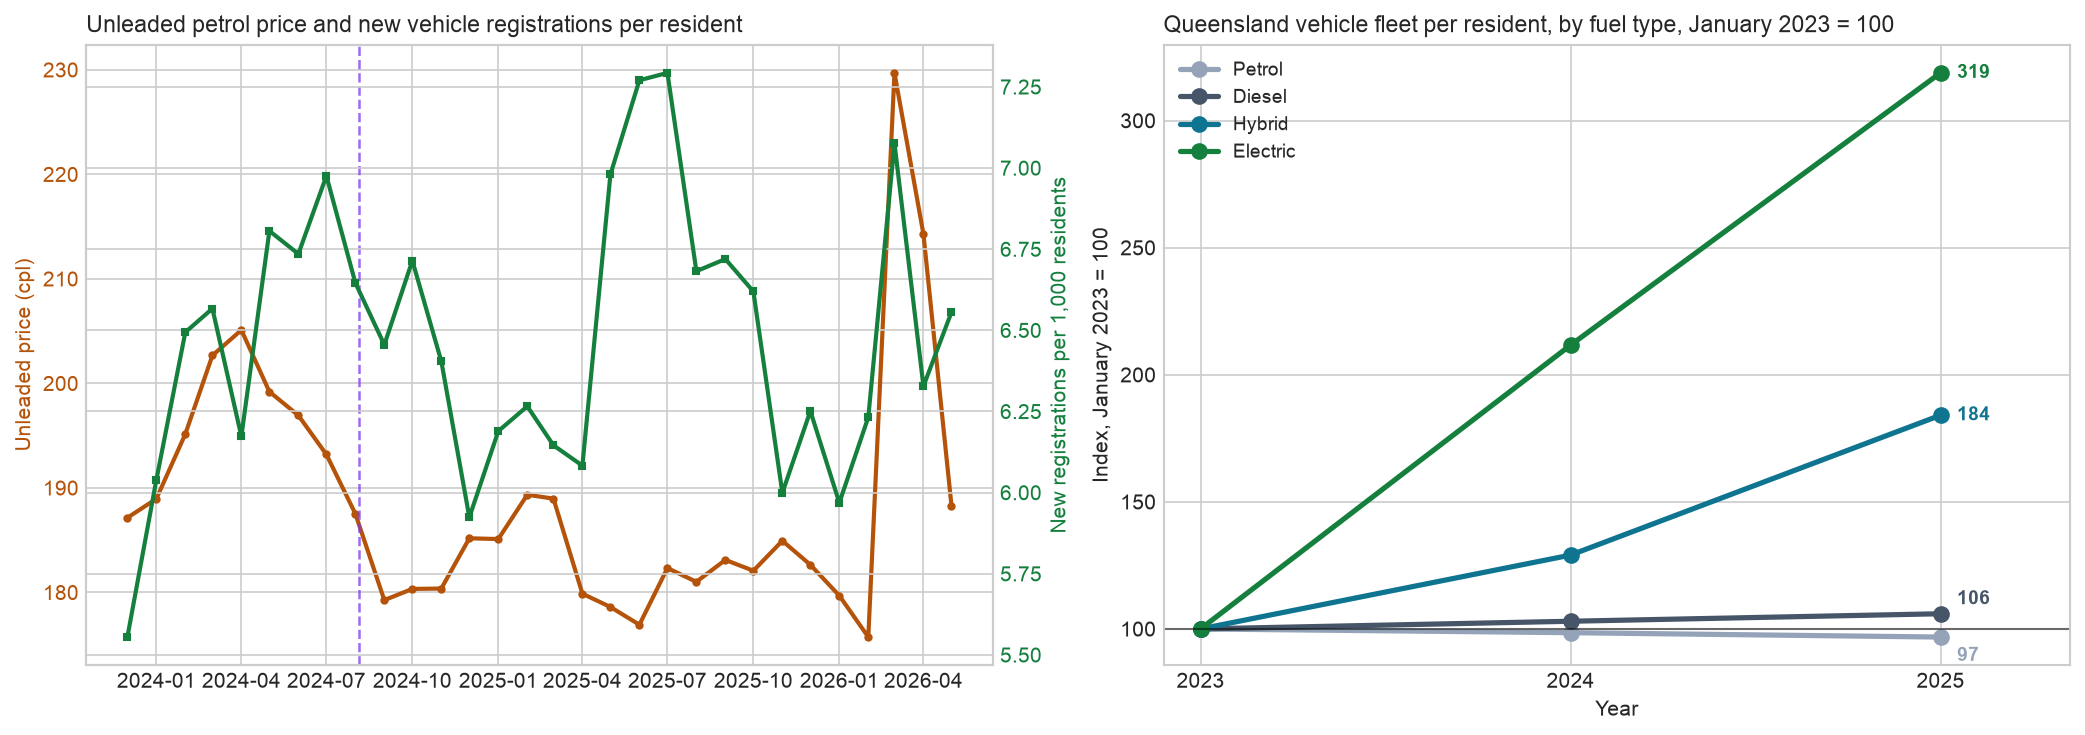

Queensland registered vehicles by fuel type (counts are the source figures):
           Jan 2023  Jan 2025  change (%)  per resident (%)
electric      16715     55661      233.00            218.80
hybrid        72461    139333       92.30             84.10
diesel      1480352   1638716       10.70              6.00
petrol      3008713   3042238        1.10             -3.20
other          3965      3289      -17.00            -20.60
dual_fuel     16420     13227      -19.40            -22.90


In [61]:
bitre_stock = pd.DataFrame({
    'year':      [2023, 2024, 2025],
    'petrol':    [3_008_713, 3_039_720, 3_042_238],
    'diesel':    [1_480_352, 1_563_982, 1_638_716],
    'dual_fuel': [   16_420,    14_800,    13_227],
    'hybrid':    [   72_461,    95_896,   139_333],
    'electric':  [   16_715,    36_280,    55_661],
    'other':     [    3_965,     3_646,     3_289],
}).set_index('year')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(analysis.index, analysis['ulp_cpl'], color=C['fuel'], lw=2, marker='o', ms=3)
ax.set_ylabel('Unleaded price (cpl)', color=C['fuel'])
ax.tick_params(axis='y', labelcolor=C['fuel'])
ax2 = ax.twinx()
ax2.plot(analysis.index, analysis['registrations_per_1000'], color=C['cars'],
         lw=2, marker='s', ms=3)
ax2.set_ylabel('New registrations per 1,000 residents', color=C['cars'])
ax2.tick_params(axis='y', labelcolor=C['cars'])
ax.set_title('Unleaded petrol price and new vehicle registrations per resident', loc='left', fontsize=11)
ax.axvline(FARE_TRIAL, **POLICY_KW)

ax = axes[1]
# Rebased to 2023 = 100. Absolute counts would be unreadable: the petrol fleet is
# ~3.0m against ~17k electric, so on a shared linear axis the small series vanish.
# Also per resident, so a fuel type that merely keeps pace with a growing state
# reads as flat rather than as growth. Population is taken at each January, the
# same dates the stock figures are measured on.
pop_jan = (pop_q.resample('MS').interpolate('time')
           .reindex([pd.Timestamp(f'{y}-01-01') for y in bitre_stock.index]))
pop_ratio = (pop_jan / pop_jan.iloc[0]).values
stock_index = bitre_stock[['petrol', 'diesel', 'hybrid', 'electric']]
stock_index = (stock_index / stock_index.loc[2023] * 100).div(pop_ratio, axis=0)
for col, colour in zip(stock_index.columns, ['#94a3b8', '#475569', '#0e7490', C['cars']]):
    ax.plot(stock_index.index, stock_index[col], marker='o', ms=7, lw=2.5,
            color=colour, label=col.capitalize())
    # Nudge the two low, near-identical series apart so their labels do not collide.
    dy = {'petrol': -9, 'diesel': 7}.get(col, 0)
    ax.annotate(f'{stock_index[col].iloc[-1]:.0f}', (stock_index.index[-1], stock_index[col].iloc[-1]),
                textcoords='offset points', xytext=(8, dy), fontsize=9, color=colour,
                va='center', fontweight='bold')
ax.axhline(100, color='black', lw=1, alpha=0.5)
ax.set_title('Queensland vehicle fleet per resident, by fuel type, January 2023 = 100',
             loc='left', fontsize=11)
ax.set_ylabel('Index, January 2023 = 100')
ax.set_xlabel('Year')
ax.legend(fontsize=9, loc='upper left')
ax.set_xticks(bitre_stock.index)
ax.set_xlim(2022.9, 2025.35)

plt.tight_layout()
plt.show()

growth = (bitre_stock.loc[2025] / bitre_stock.loc[2023] - 1) * 100
# Per-resident change for every fuel type, including the two the panel does not
# plot: (1 + growth) divided by the population ratio, minus one.
per_head = ((1 + growth / 100) / pop_ratio[-1] - 1) * 100
counts = pd.DataFrame({'Jan 2023': bitre_stock.loc[2023], 'Jan 2025': bitre_stock.loc[2025],
                       'change (%)': growth.round(1),
                       'per resident (%)': per_head.round(1)}).sort_values('change (%)', ascending=False)
print('Queensland registered vehicles by fuel type (counts are the source figures):')
print(counts.to_string())

**What to look for.** Every line is per resident, and that changes how the flat ones read. On
raw counts the petrol fleet looks almost flat, up about 1% over two years; per resident it falls
outright, because Queensland added people faster than it added petrol cars. Diesel, hybrid and
electric all still grow on either reading, and the ordering of the four never changes — the
adjustment moves the level, not the ranking. That composition shift is far too steady to be a
response to a fuel price that moved by 20 cents either way; it is a multi-year trend that starts
before our window. In the flow panel the question is whether registrations dip when the fuel
price spikes in 2026, but that spike coincides with the fare already being in place, and the
count is per 1,000 residents so that a growing state cannot be mistaken for growing car demand.

In [62]:
# Does the fuel price lead registrations? Correlate month-to-month changes at lags 0-6.
fuel_chg = analysis['ulp_cpl'].diff()
reg_chg = analysis['registrations_per_1000'].diff()
lag_corr = pd.Series({lag: fuel_chg.corr(reg_chg.shift(-lag)) for lag in range(0, 7)},
                     name='correlation')
print('Correlation between a fuel price change and the registration change k months later:')
print(lag_corr.round(3).to_string())
print(f'\nEach estimate rests on about {len(reg_chg.dropna()) - 6} observations. '
      'Nothing here is distinguishable from noise.')

Correlation between a fuel price change and the registration change k months later:
0    0.34
1   -0.45
2    0.09
3    0.34
4    0.22
5    0.03
6    0.03

Each estimate rests on about 23 observations. Nothing here is distinguishable from noise.


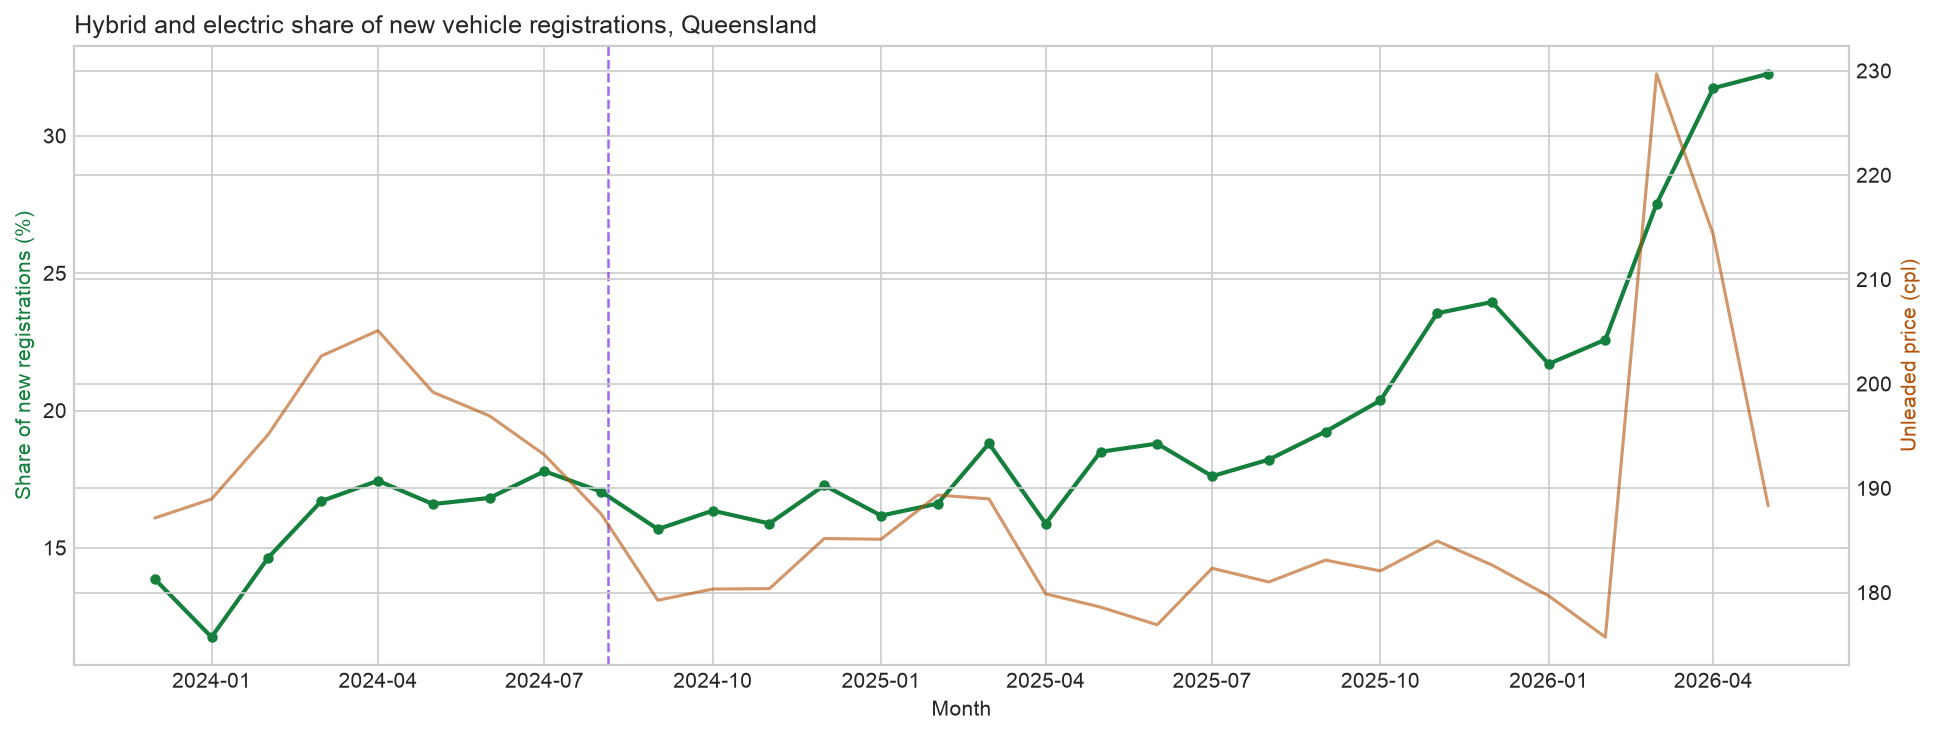

Hybrid/electric share: 13.9% in Dec 2023 -> 32.3% in May 2026
Correlation with the fuel price, levels:               +0.34
Correlation with the fuel price, month-to-month change: +0.42


In [63]:
# The composition question -- the one fuel prices plausibly do move.
# A high running cost makes an efficient car more attractive at the point of purchase.
electrified = share['Hybrid'] + share['Electric']
corr_levels_alt = electrified.corr(analysis['ulp_cpl'])
corr_chg_alt = electrified.diff().corr(analysis['ulp_cpl'].diff())

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(electrified.index, electrified, color=C['cars'], marker='o', ms=4, lw=2)
ax.set_ylabel('Share of new registrations (%)', color=C['cars'])
ax.set_title('Hybrid and electric share of new vehicle registrations, Queensland', loc='left')
ax.set_xlabel('Month')
ax.axvline(FARE_TRIAL, **POLICY_KW)
ax2 = ax.twinx()
ax2.plot(analysis.index, analysis['ulp_cpl'], color=C['fuel'], lw=1.5, alpha=0.6)
ax2.set_ylabel('Unleaded price (cpl)', color=C['fuel'])
plt.tight_layout()
plt.show()

print(f'Hybrid/electric share: {electrified.iloc[0]:.1f}% in {electrified.index[0]:%b %Y} '
      f'-> {electrified.iloc[-1]:.1f}% in {electrified.index[-1]:%b %Y}')
print(f'Correlation with the fuel price, levels:               {corr_levels_alt:+.2f}')
print(f'Correlation with the fuel price, month-to-month change: {corr_chg_alt:+.2f}')

**Do not read the second number as evidence.** The share rises in almost every month of the
window — it is close to a straight line. Two series that each drift steadily will correlate
with each other and with almost anything else, so both figures are picking up shared drift
rather than a response to fuel. Differencing once is not enough to remove a trend this smooth:
the change correlation comes out at +0.42, higher than the levels correlation of +0.34, which is
the opposite of what a genuine month-to-month response would look like.

What would separate the two explanations is a *fuel price shock* — a sharp, isolated move with
no matching move in incomes or model availability — and the later 2026 spike is not clean
enough for that, because EV incentives, model launches and the Nov 2025 federal efficiency
standard all change over the same months. We report the pattern and stop short of attributing
it.

**4.5 RQ5 — all four together.** Fitting all four at once on 30 monthly observations would
produce coefficients that look precise and mean very little. What is defensible is one
descriptive regression per outcome, reported with uncertainty and its obvious weaknesses.

In [64]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

# Population belongs in the frame, so the fare coefficient can be read per
# resident rather than absorbing a rising denominator.
analysis['population'] = pop_monthly
analysis['trips_per_resident'] = trips_per_resident
# Year-on-year change in trips per resident. The twelve-month lag has to be taken
# before the transition month is dropped, or the lag would reach back over a gap.
analysis['yoy_rate'] = analysis['trips_per_resident'].pct_change(12, fill_method=None) * 100

reg_data = analysis.dropna(subset=['fare_50c'])

# Three specifications, every outcome per resident. Errors are HAC (Newey-West,
# 3 lags), the honest choice for monthly data whose residuals are serially
# correlated. The year-on-year column cannot carry the fare -- a frame reaching
# back twelve months survives only in months that are already post-policy, where
# the dummy is constant -- so it is there to test whether fuel explains growth
# that population and the fare between them have not.
SPECS = [
    ('Patronage per resident',      'trips_per_resident',     'Trips per person',
     ['fare_50c', 'ulp_cpl']),
    ('Patronage per resident, YoY', 'yoy_rate',               'Change vs year earlier (%)',
     ['ulp_cpl']),
    ('Registrations per 1,000',     'registrations_per_1000', 'Per 1,000 residents',
     ['fare_50c', 'ulp_cpl']),
]


def fit(outcome, terms):
    y = reg_data[outcome]
    X = sm.add_constant(reg_data[terms])
    ok = X.notna().all(axis=1) & y.notna()
    return sm.OLS(y[ok], X[ok]).fit(cov_type='HAC', cov_kwds={'maxlags': 3})


fitted = {name: fit(outcome, terms) for name, outcome, _, terms in SPECS}

for name, outcome, units, terms in SPECS:
    m = fitted[name]
    print('=' * 78)
    print(name)
    print(f'Dependent variable: {units}')
    print('=' * 78)
    print(m.summary())
    print(f'Durbin-Watson: {durbin_watson(m.resid):.3f}')
    print()

print('Significance: *** p<0.01, ** p<0.05, * p<0.1.')
print('The fare row is blank in the year-on-year column because the dummy is')
print('constant there and cannot be estimated.')
n_levels = int(fitted['Patronage per resident'].nobs)
n_yoy = int(fitted['Patronage per resident, YoY'].nobs)
print(f'The two levels models use {n_levels} months -- August 2024 is dropped because')
print(f'the fare changed part-way through it. The year-on-year model uses {n_yoy},')
print('having spent twelve of them on the lag.')

Patronage per resident
Dependent variable: Trips per person
                            OLS Regression Results                            
Dep. Variable:     trips_per_resident   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     19.09
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           7.91e-06
Time:                        14:30:46   Log-Likelihood:                -3.7707
No. Observations:                  29   AIC:                             13.54
Df Residuals:                      26   BIC:                             17.64
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

**What the population column does — and why it does it.** It changes the answer, and the
honest reading is more interesting than the convenient one. Counted per resident the fare
coefficient is 0.64 extra trips per person per month, significant at p < 0.001. On raw levels
the same model returns 3.99 million trips without a population control and 1.73 with one, at
which point it is no longer significant (p = 0.17). Those two raw-level numbers come from a
model that is not in the table above, and they are quoted here precisely because dropping it
silently would make the per-resident estimate look more solid than the design supports.

That is **not** because population explains the rise. The year-on-year decomposition above
shows population accounts for only about 1.7 of the 13.8 points. It happens because a fare
step that switches on once and never off is, over a 29-month window with only 8 pre-policy
months, nearly indistinguishable from a steady upward population trend. The two compete for
the same variation and the regression cannot tell them apart. That is a limitation of the
design, not a null result.

The per-resident model avoids the problem by dividing population out *before* fitting, rather
than asking the regression to separate two collinear series, and that is the coefficient to
quote. The levels model is not a second opinion on it — it is the same data with an
identification problem, which is why it has been taken out of the table.

**One number in the table needs a warning.** In the year-on-year column the fuel price carries
a positive coefficient on trips per resident (0.375, significant at 5%), which on its face says
that dearer petrol puts people on trains. Treat it as the confound it is. The 2026 fuel spike
falls in the same months as the highest patronage readings in the window, so the two move
together at the end of the series; with 18 observations and no way to separate them, the
coefficient absorbs the coincidence. The caution runs the other way too: because the fare dummy
is constant in that frame, the column cannot say anything about the fare. It is reported for
completeness, not as a rival explanation.

Do not read those p-values as causal evidence all the same, for three reasons. The fare
variable is a step rather than an experiment: it switches on once and never off, so it is
nearly collinear with time itself, and its coefficient absorbs everything else that changed
after August 2024 — service levels, post-pandemic recovery, the fuel spike. Population is the
one of these we can put in the model, which is why the population adjustment matters more than
its size suggests: it is the only competing explanation we can rule out with the data. There is
also no control group, since everything here is Queensland, and without a comparable state that
did not cut fares the policy cannot be separated from the trend. And lagged effects are
invisible: travel habits take months to change, and a car purchase responds over a much longer
horizon than this window covers.

**The registration column, read on its own terms.** New registrations is the one column in
the table above that comes back empty -- R-squared 0.03, with neither the fare nor the fuel
price distinguishable from zero. A null that flat deserves to be pressed on rather than
reported and stepped past, because this column carries the same population problem the
patronage column carries, and the two available ways of handling it do not have to agree.

Three specifications, all using the terms above. **R1** is the column already reported:
registrations per 1,000 residents, so population is divided out before the fit. **R2** keeps
registrations as a raw count, and **R3** adds population as a regressor instead of a
denominator. The contrast between R2 and R3 is the one drawn for patronage just above, and
it is what decides whether an absent effect is a real one or an artefact of how the outcome
was scaled.

In [65]:
# The registration column is the weakest fit in the table above, and the honest
# thing to do with a null is to test whether it survives the same treatment the
# patronage column got. It does not turn into a finding -- but the comparison is
# what says the null is not manufactured by the population adjustment, which is
# the charge the fare column would otherwise have to answer.
#
# R1 is the column already reported. R2 and R3 keep registrations as a count and
# differ only in whether population enters as a regressor, which is exactly the
# contrast drawn for patronage just above.
CAR_SPECS = [
    ('R1  registrations per 1,000 residents', 'registrations_per_1000', ['fare_50c', 'ulp_cpl']),
    ('R2  new registrations, raw count',      'new_registrations',      ['fare_50c', 'ulp_cpl']),
    ('R3  raw count + population',            'new_registrations',      ['fare_50c', 'ulp_cpl', 'population']),
]

car_fits = {}
for name, outcome, terms in CAR_SPECS:
    y = reg_data[outcome]
    X = sm.add_constant(reg_data[terms])
    ok = X.notna().all(axis=1) & y.notna()
    car_fits[name] = sm.OLS(y[ok], X[ok]).fit(cov_type='HAC', cov_kwds={'maxlags': 3})


# Coefficients are in the units of their own outcome -- registrations in R2 and R3,
# registrations per 1,000 residents in R1 -- so the levels are not comparable down
# a column. The sign, the p-value and the fit are, and those are what the rows are
# here to be read against each other for.
def _fmt(m, term):
    if term not in m.params.index:
        return '--'
    p = m.pvalues[term]
    star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    return f'{m.params[term]:,.2f}{star} (p={p:.3f})'


car_table = pd.DataFrame([
    {'Specification': name, 'n': int(m.nobs), 'R2': round(m.rsquared, 3),
     'Durbin-Watson': round(durbin_watson(m.resid), 2),
     '50c fare': _fmt(m, 'fare_50c'), 'Fuel price': _fmt(m, 'ulp_cpl'),
     'Population': _fmt(m, 'population')}
    for name, m in [(name, car_fits[name]) for name, _, _ in CAR_SPECS]
]).set_index('Specification')

first = car_fits[CAR_SPECS[0][0]]
print('New vehicle registrations, Queensland -- three specifications')
print(f'{int(first.nobs)} months, {reg_data.index.min():%b %Y} -> {reg_data.index.max():%b %Y}. '
      'HAC (Newey-West, 3 lags) standard errors.')
print(car_table.to_string())
print()
print('Significance: *** p<0.01, ** p<0.05, * p<0.1.')

m2, m3 = car_fits['R2  new registrations, raw count'], car_fits['R3  raw count + population']
print(f'Adding population moves the fare coefficient from {m2.params["fare_50c"]:+,.0f} '
      f'registrations a month to {m3.params["fare_50c"]:+,.0f}, and it is not significant '
      f'either way (p = {m2.pvalues["fare_50c"]:.2f} and {m3.pvalues["fare_50c"]:.2f}).')

New vehicle registrations, Queensland -- three specifications
29 months, Dec 2023 -> May 2026. HAC (Newey-West, 3 lags) standard errors.
                                        n   R2  Durbin-Watson            50c fare       Fuel price      Population
Specification                                                                                                     
R1  registrations per 1,000 residents  29 0.03           0.97      0.13 (p=0.553)   0.01 (p=0.284)              --
R2  new registrations, raw count       29 0.09           0.96  1,646.64 (p=0.200)  47.07 (p=0.155)              --
R3  raw count + population             29 0.14           0.97   -349.81 (p=0.855)  24.21 (p=0.612)  0.01 (p=0.236)

Significance: *** p<0.01, ** p<0.05, * p<0.1.
Adding population moves the fare coefficient from +1,647 registrations a month to -350, and it is not significant either way (p = 0.20 and 0.86).


**Read the signs, not the levels.** The three rows are not on a common scale -- R2 and R3
count registrations, R1 counts them per 1,000 residents -- so what compares across them is
the sign, the p-value and the fit, and on all three the answer is the same: no detectable
fare or fuel price effect on how many vehicles Queensland registers.

The population control behaves differently here than it did for patronage, and the
difference is the useful part. For patronage, adding population was what removed the fare
effect -- 3.99 million trips fell to 1.73 and out of significance -- which is the signature
of a denominator doing the work. For registrations the fare coefficient is insignificant
*before* population is added as well as after: R2 gives +1,647 registrations a month at
p = 0.20, R3 gives -350 at p = 0.86. There was no effect for the population control to
remove, so the null is not an artefact of the adjustment.

**The fit statistic is the warning.** Durbin-Watson sits at about 0.97 in all three
specifications, which is strong positive serial correlation. The residuals still carry most
of a seasonal shape the model has no terms for, because registrations peak in the same
months every year while the regressors here are a step and a price. The HAC errors widen
the intervals to allow for that, which is why nothing is significant, but widening an
interval is not the same as having the information to narrow it. With 29 months, eight of
them before the policy, no specification of this shape could have said much more.

That is why the null is better read as a limit of the window than as evidence that fares
leave cars alone. A new-vehicle registration is a purchase made on a horizon of years
against a fleet that turns over slowly -- the stock panel above moves on the scale of a
decade, not a quarter. Nothing here could register a response that takes longer to arrive
than the window is long, and the fare is a public transport price acting on a decision --
whether to own a car at all -- that this data observes only at the moment of purchase.

---


**4.6 Forecasting petrol use and roadside NO2 around the fare.** The sections above read the
fare, the fuel price and car-buying off one 30-month window in which the fare switches on once.
This section asks the same two questions — did the fare cut driving, and did it cut the pollution
beside the road? — from the other end. Instead of asking whether two series moved together, it
builds a model of what each series *would have done* had the fare never changed, and reads the
fare as the distance between that counterfactual and what actually happened.

Two model-ready files do the work. They come from the wider project's fuel and air-quality work
rather than from this notebook's own sources, so they extend the window well past May 2026 and
reach further back than 2023:

| File | One row is | Column forecast | Window |
|---|---|---|---|
| `model_ready/petrol_monthly.csv` | one month | `qld_litres_pp`, litres of petrol per Queenslander | Jul 2010 – Jun 2026 |
| `model_ready/no2_daily.csv` | one day | `no2_ppb`, nitrogen dioxide beside a busy road in South Brisbane | Jan 2016 – Dec 2025 |

**The split is given, not chosen.** Each file carries a `split` column, and the whole group
follows it so the numbers line up: `train` fits the model; `validation` (Aug 2023 – Jul 2024, the
last normal year) is the untouched year every model is compared on; `policy` is predicted and
never trained on; and `unused` — COVID, the floods and the cyclone — is dropped. Tuning happens
inside `train` alone, against the year Aug 2022 – Jul 2023 held back from its end, because a
validation year stops being a fair comparison the moment somebody tunes on it.

**Two of the guide's four models, so the two can be read against each other.** *Gradient boosting*
(green `#1baf7a`, LightGBM) is the one that has to be defended against its own capacity: petrol
offers 93 training rows, and a tree ensemble at default settings will memorise them, so its grid
is deliberately small — shallow trees, and few of them. *Linear regression* (orange `#eb6834`,
plain least squares) is the opposite bet: it cannot bend to any shape, so whatever it finds has to
hold as a straight line. Where the tree model bends to fit a season the line cannot see, the two
will disagree, and that disagreement is the point of running both. The guide's other two models
(Prophet, SARIMAX) are built by other members against these same files and this same split.

**One modelling choice worth naming, and it applies to the tree model only.** Gradient boosting
forecasts petrol as `qld_litres_pp / ctrl_litres_pp`, the ratio to the same quantity in New South
Wales and Victoria, and multiplies the control back in afterwards. A tree ensemble cannot predict
a value lower than the lowest it saw in training, and Queensland's petrol use keeps falling, so the
ratio lets it follow the control states down instead of flattening out at the floor of the training
data. The linear model forecasts litres per person directly: a straight line has no such floor, and
the ratio would only cost it the level information it is entitled to use.

**The three numbers, all in per cent.** *Error* is the average absolute percentage miss over the
validation year, one row at a time, and says how closely the model tracks a period it has never
seen. *Bias* is total predicted against total actual over the same year, and says whether the model
runs high or low overall. *Gap* is `(total actual − total predicted) / total predicted` over the
policy months, signed so that negative means less petrol burned, or less NO2 in the air, than the
pre-fare relationship implied.


In [66]:
import itertools
import lightgbm as lgb

# The group's modelling guide lives beside the two files, and everything below
# follows it so our numbers sit next to everyone else's: the same split column, the
# same input columns, the same three metrics, the same chart colours. statsmodels is
# already imported for section 4.5.
MODEL_DIR = ROOT / 'model_ready'
MODEL_OUT = MODEL_DIR / 'outputs'   # charts and prediction CSVs are written here
MODEL_OUT.mkdir(parents=True, exist_ok=True)

# One colour and one file tag per model, taken from the guide's table.
MODELS = {
    'Gradient boosting': dict(colour='#1baf7a', tag='boosting'),
    'Linear regression': dict(colour='#eb6834', tag='linear'),
}
GB_BASE = dict(random_state=0, verbose=-1)

petrol = pd.read_csv(MODEL_DIR / 'petrol_monthly.csv', parse_dates=['month'])
no2 = pd.read_csv(MODEL_DIR / 'no2_daily.csv', parse_dates=['date'])
# rain_mm carries no reading before mid-2016. The guide fills it with zero rather
# than dropping those months, which costs a little accuracy in 2016 and keeps every
# model in the group on exactly the same rows.
no2['rain_mm'] = no2['rain_mm'].fillna(0)

PETROL_CTRL = 'ctrl_litres_pp'
PETROL_INPUTS = [PETROL_CTRL, 'month_of_year', 'days_in_month']
PETROL_EXTRA = ['ctrl_all_litres_pp', 'month_of_year', 'days_in_month']

NO2_INPUTS = ['wind_speed', 'wind_u', 'wind_v', 'temp_c', 'temp_min_c', 'humidity_pct',
              'pressure_hpa', 'rain_mm', 'day_of_week', 'day_of_year',
              'is_public_holiday', 'is_school_holiday',
              # `t` is the running day count. Pollution stepped down in 2020 and
              # stayed down, and a tree model cannot extrapolate a level it has not
              # seen, so it is handed the step directly instead of being left to
              # infer it from the year.
              't']
NO2_EXTRA = NO2_INPUTS + ['bg_no2_ppb']   # extra run: the quiet suburban monitor
# The guide gives the tree model a running counter here and the linear models a
# dummy instead: a straight line can read a step down in 2020 as a step, but a
# counter would only hand it a trend to extrapolate past the end of the data.
NO2_LINEAR_INPUTS = [c for c in NO2_INPUTS if c != 't'] + ['post_covid']
NO2_LINEAR_EXTRA = NO2_LINEAR_INPUTS + ['bg_no2_ppb']

# One gap the guide does not cover. LightGBM treats a missing input as its own
# signal and carries on; least squares refuses the fit outright. Rather than drop
# those days -- 23 of them in training, 5 of them in the policy period -- they are
# filled with the median of the training rows, so that both models are scored on
# exactly the same days and the comparison between them stays like for like. The
# medians come from `train` alone, so nothing after the fare reaches back into the
# fit. Only the linear model sees this frame; the tree model gets the gaps.
no2_filled = no2.copy()
LINEAR_COLS = sorted(set(NO2_LINEAR_EXTRA))
no2_filled[LINEAR_COLS] = no2_filled[LINEAR_COLS].fillna(
    no2.loc[no2['split'] == 'train', LINEAR_COLS].median())

print('Rows handed to each model, by split:')
print(pd.DataFrame({
    'rows': [len(petrol), len(no2)],
    'train': [(petrol['split'] == 'train').sum(), (no2['split'] == 'train').sum()],
    'validation': [(petrol['split'] == 'validation').sum(),
                   (no2['split'] == 'validation').sum()],
    'policy': [(petrol['split'] == 'policy').sum(), (no2['split'] == 'policy').sum()],
    'unused': [(petrol['split'] == 'unused').sum(), (no2['split'] == 'unused').sum()],
}, index=['petrol', 'no2']).to_string())


Rows handed to each model, by split:
        rows  train  validation  policy  unused
petrol   192     93          12      23      64
no2     3653   2667         370     508     108


**Only the tree model has settings, and they are tuned inside `train` alone.** The guide holds
back the last year of the training rows — August 2022 to July 2023 — fits each candidate setting on
everything before it, and keeps the setting with the lowest error on the year held back. It asks for
plain linear regression, which has nothing to tune; had it been Ridge or Lasso there would be an
`alpha` to choose here as well. Nothing in this section looks at the validation or policy rows,
which is what makes the validation columns further down comparable across the group's four models.
The settings tried and the ones kept are both printed, because the report has to carry them.


In [67]:
def score(actual, predicted):
    """The guide's three numbers, in per cent, for one set of predictions."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    ok = np.isfinite(actual) & np.isfinite(predicted)
    actual, predicted = actual[ok], predicted[ok]
    return {
        # One row at a time: the average absolute percentage miss.
        'Error': float(np.mean(np.abs(predicted - actual) / actual) * 100),
        # Totals against totals: does the model run high or low overall?
        'Bias': float((predicted.sum() - actual.sum()) / actual.sum() * 100),
        # On the policy months this is the fare effect, signed so a negative number
        # means less petrol or less pollution than the pre-fare fit implied.
        'Gap': float((actual.sum() - predicted.sum()) / predicted.sum() * 100),
    }


def boosting_fitter(params):
    """A fit(X, y) for LightGBM, so both models share one runner."""
    def fit(x, y):
        return lgb.LGBMRegressor(**GB_BASE, **params).fit(x, y)
    return fit


class LeastSquares:
    """Plain least squares, wearing the same one-call interface as LightGBM.

    statsmodels needs the intercept column present when predicting as well as when
    fitting, so the wrapper adds it in both places rather than leaving that to the
    caller. `has_constant='add'` is not optional here: `post_covid` is 1 in every
    validation and policy row, and at its default statsmodels reads any constant
    column as the intercept and adds nothing, which leaves the fitted and predicted
    design matrices a column apart. Nothing is tuned -- the guide asks for plain
    linear regression.
    """

    def __init__(self, x, y):
        self.x = x
        self.result = sm.OLS(y, sm.add_constant(x, has_constant='add')).fit()

    def predict(self, x):
        return self.result.predict(sm.add_constant(x, has_constant='add'))


def run_petrol(df, ctrl, fit, ratio=True):
    """Fit on train, predict validation, refit on both, predict policy.

    With `ratio=True` the model forecasts `qld_litres_pp / ctrl` and the control is
    multiplied back in, which is what the guide asks of the tree model. With
    `ratio=False` it forecasts litres per person directly, which is what the linear
    model does.
    """
    base = df.copy()
    base['target'] = base['qld_litres_pp'] / base[ctrl] if ratio else base['qld_litres_pp']
    inputs = [ctrl, 'month_of_year', 'days_in_month']

    tr = base[base['split'] == 'train'].dropna(subset=['target'])
    va = base[base['split'] == 'validation'].dropna(subset=['target'])
    po = base[base['split'] == 'policy'].dropna(subset=['target'])

    first = fit(tr[inputs], tr['target'])
    parts = [pd.DataFrame({'date': va['month'], 'actual': va['qld_litres_pp'],
                           'predicted': first.predict(va[inputs]) * (va[ctrl] if ratio else 1),
                           'split': 'validation'})]
    # Refit with the validation year added, then predict the months after the fare.
    both = pd.concat([tr, va])
    second = fit(both[inputs], both['target'])
    parts.append(pd.DataFrame({'date': po['month'], 'actual': po['qld_litres_pp'],
                               'predicted': second.predict(po[inputs]) * (po[ctrl] if ratio else 1),
                               'split': 'policy'}))
    return pd.concat(parts, ignore_index=True), second


def run_no2(df, inputs, fit):
    """The same three steps for the daily roadside series.

    A handful of days have no reading, including eleven in the policy period. They
    are dropped rather than filled: a missing instrument reading is not a clean-air
    day, and counting it as zero would manufacture the effect we are testing for.
    """
    tr = df[df['split'] == 'train'].dropna(subset=['no2_ppb'])
    va = df[df['split'] == 'validation'].dropna(subset=['no2_ppb'])
    po = df[df['split'] == 'policy'].dropna(subset=['no2_ppb'])

    first = fit(tr[inputs], tr['no2_ppb'])
    parts = [pd.DataFrame({'date': va['date'], 'actual': va['no2_ppb'],
                           'predicted': first.predict(va[inputs]), 'split': 'validation'})]
    both = pd.concat([tr, va])
    second = fit(both[inputs], both['no2_ppb'])
    parts.append(pd.DataFrame({'date': po['date'], 'actual': po['no2_ppb'],
                               'predicted': second.predict(po[inputs]), 'split': 'policy'}))
    return pd.concat(parts, ignore_index=True), second


In [68]:
HOLDBACK = pd.Timestamp('2022-08-01')    # the last year inside `train`


def grid(**settings):
    """Every combination of the settings given, as a list of parameter dicts."""
    return [dict(zip(settings, values)) for values in itertools.product(*settings.values())]


# Petrol's grid is small on purpose. Ninety-three rows will not support a deep
# ensemble, so the largest tree tried here has four leaves and the largest forest 400.
PETROL_GRID = grid(num_leaves=[2, 4], n_estimators=[200, 400],
                   learning_rate=[0.03, 0.05], min_child_samples=[5, 10])
NO2_GRID = grid(num_leaves=[15, 31], n_estimators=[300, 600],
                learning_rate=[0.05], min_child_samples=[20, 50])


# Each row keeps the candidate settings as a dict as well as flattened into
# columns. The flattened copy is what gets printed, but it is not what gets passed
# back to LightGBM: a frame with a float Error column upcasts the whole row, which
# would hand LightGBM n_estimators=400.0 and it rejects that outright.
def tune_petrol(df, ctrl, candidates):
    base = df.copy()
    base['ratio'] = base['qld_litres_pp'] / base[ctrl]
    inputs = [ctrl, 'month_of_year', 'days_in_month']
    tr = base[base['split'] == 'train'].dropna(subset=['ratio'])
    early, held = tr[tr['month'] < HOLDBACK], tr[tr['month'] >= HOLDBACK]
    tried = []
    for params in candidates:
        m = lgb.LGBMRegressor(**GB_BASE, **params).fit(early[inputs], early['ratio'])
        pred = m.predict(held[inputs]) * held[ctrl]
        tried.append({**params, 'settings': params,
                      'Error': score(held['qld_litres_pp'], pred)['Error']})
    return pd.DataFrame(tried).sort_values('Error').reset_index(drop=True)


def tune_no2(df, inputs, candidates):
    tr = df[df['split'] == 'train'].dropna(subset=['no2_ppb'])
    early, held = tr[tr['date'] < HOLDBACK], tr[tr['date'] >= HOLDBACK]
    tried = []
    for params in candidates:
        m = lgb.LGBMRegressor(**GB_BASE, **params).fit(early[inputs], early['no2_ppb'])
        tried.append({**params, 'settings': params,
                      'Error': score(held['no2_ppb'], m.predict(held[inputs]))['Error']})
    return pd.DataFrame(tried).sort_values('Error').reset_index(drop=True)


petrol_tuning = tune_petrol(petrol, PETROL_CTRL, PETROL_GRID)
no2_tuning = tune_no2(no2, NO2_INPUTS, NO2_GRID)
PETROL_BEST = petrol_tuning.loc[0, 'settings']
NO2_BEST = no2_tuning.loc[0, 'settings']

print(f'Settings tried on petrol ({len(petrol_tuning)}), lowest held-back error first:')
print(petrol_tuning.drop(columns='settings').round(3).to_string(index=False))
print()
print(f'Settings tried on NO2 ({len(no2_tuning)}), lowest held-back error first:')
print(no2_tuning.drop(columns='settings').round(3).to_string(index=False))
print()
print(f'Kept for petrol: {PETROL_BEST}')
print(f'Kept for NO2:    {NO2_BEST}')
print()
print('The tuning year, Aug 2022 - Jul 2023, held back from `train`: '
      f'{(petrol[(petrol["split"] == "train") & (petrol["month"] >= HOLDBACK)].shape[0])} '
      'petrol months and '
      f'{(no2[(no2["split"] == "train") & (no2["date"] >= HOLDBACK)].shape[0])} NO2 days.')


Settings tried on petrol (16), lowest held-back error first:
 num_leaves  n_estimators  learning_rate  min_child_samples  Error
          4           400           0.03                  5   1.55
          4           200           0.05                  5   1.56
          4           200           0.03                  5   1.63
          4           400           0.05                  5   1.64
          4           400           0.05                 10   1.77
          4           400           0.03                 10   1.80
          4           200           0.05                 10   1.83
          4           200           0.03                 10   1.86
          2           200           0.03                  5   2.06
          2           400           0.05                  5   2.07
          2           200           0.05                  5   2.08
          2           400           0.03                  5   2.08
          2           200           0.03                 10   2.22
 

**The main run, then the extra run, for each model.** With the settings settled, each model is
fitted on `train` and asked to predict the validation year, which gives the error and the bias; then
refitted with the validation year added, and asked to predict the policy months, which gives the gap.
The extra run repeats both steps with one input changed — petrol against every other state combined
instead of just New South Wales and Victoria, NO2 with the quiet suburban monitor added as an input —
so that a headline resting on which control series we happened to pick shows up as a disagreement
between the two runs rather than as a finding.


In [69]:
petrol_gb, petrol_gb_model = run_petrol(petrol, PETROL_CTRL, boosting_fitter(PETROL_BEST))
petrol_gb_extra, _ = run_petrol(petrol, 'ctrl_all_litres_pp', boosting_fitter(PETROL_BEST))
no2_gb, no2_gb_model = run_no2(no2, NO2_INPUTS, boosting_fitter(NO2_BEST))
no2_gb_extra, _ = run_no2(no2, NO2_EXTRA, boosting_fitter(NO2_BEST))

petrol_lr, petrol_lr_model = run_petrol(petrol, PETROL_CTRL, LeastSquares, ratio=False)
petrol_lr_extra, _ = run_petrol(petrol, 'ctrl_all_litres_pp', LeastSquares, ratio=False)
no2_lr, no2_lr_model = run_no2(no2_filled, NO2_LINEAR_INPUTS, LeastSquares)
no2_lr_extra, _ = run_no2(no2_filled, NO2_LINEAR_EXTRA, LeastSquares)

RUNS = {
    ('Gradient boosting', 'petrol', 'main'): petrol_gb,
    ('Gradient boosting', 'petrol', 'extra'): petrol_gb_extra,
    ('Gradient boosting', 'NO2', 'main'): no2_gb,
    ('Gradient boosting', 'NO2', 'extra'): no2_gb_extra,
    ('Linear regression', 'petrol', 'main'): petrol_lr,
    ('Linear regression', 'petrol', 'extra'): petrol_lr_extra,
    ('Linear regression', 'NO2', 'main'): no2_lr,
    ('Linear regression', 'NO2', 'extra'): no2_lr_extra,
}


def summarise(preds):
    """Error and bias from the validation year, gap from the policy months."""
    va = preds[preds['split'] == 'validation']
    po = preds[preds['split'] == 'policy']
    return {'Error': score(va['actual'], va['predicted'])['Error'],
            'Bias': score(va['actual'], va['predicted'])['Bias'],
            'Gap': score(po['actual'], po['predicted'])['Gap']}


results = pd.DataFrame([{'Model': m, 'File': f, 'Run': r, **summarise(p)}
                        for (m, f, r), p in RUNS.items()])
print('Both models, both files, both runs (per cent):')
print(results.round(2).to_string(index=False))
print()
print('Error and Bias are measured on the validation year; Gap is the policy months.')
print('A negative Gap means less petrol, or less NO2, than the pre-fare fit predicted.')

# The linear model's coefficients, for the reading. Petrol only has three terms, so
# the whole fitted equation is readable; NO2 has thirteen and is left to the chart.
print()
print(f'Linear regression on petrol (target: litres per person), '
      f'{int(petrol_lr_model.result.nobs)} training rows, R2 '
      f'{petrol_lr_model.result.rsquared:.3f}:')
print(petrol_lr_model.result.params.round(4).to_string())

print()
print('Durbin-Watson on the fitted residuals -- near 2 is clean, near 0 means the')
print('residuals still carry a pattern the terms above cannot express. Section 4.5')
print('found the same problem in the monthly regressions:')
for name, model in [('petrol', petrol_lr_model), ('NO2', no2_lr_model)]:
    print(f'  {name:>6}: {sm.stats.durbin_watson(model.result.resid):.2f}')


Both models, both files, both runs (per cent):
            Model   File   Run  Error  Bias   Gap
Gradient boosting petrol  main   3.60  0.53 -3.86
Gradient boosting petrol extra   3.50  1.17 -2.61
Gradient boosting    NO2  main  15.79  4.87  2.86
Gradient boosting    NO2 extra  12.30 -2.08  3.37
Linear regression petrol  main   2.51  0.81 -4.01
Linear regression petrol extra   2.49  1.27 -2.82
Linear regression    NO2  main  24.87  6.41  2.65
Linear regression    NO2 extra  17.50  3.03  5.22

Error and Bias are measured on the validation year; Gap is the policy months.
A negative Gap means less petrol, or less NO2, than the pre-fare fit predicted.

Linear regression on petrol (target: litres per person), 105 training rows, R2 0.927:
const            -4.53
ctrl_litres_pp    1.04
month_of_year    -0.10
days_in_month     0.10

Durbin-Watson on the fitted residuals -- near 2 is clean, near 0 means the
residuals still carry a pattern the terms above cannot express. Section 4.5
found the sam

**The charts the guide asks for.** Three per model per file, in the group's layout so they can
sit beside the other members' models: actual against predicted over time, the gap month by month, and
predicted against actual over the validation year only. The red line is 5 August 2024 and the grey
band is the validation year. Petrol is read in litres per person; NO2's daily series swings too far
to read, so it is averaged by month first, as the guide requires.

Each model then gets the fourth chart the guide reserves for it: feature importance for gradient
boosting, and coefficients for linear regression. The coefficient bars are scaled by one standard
deviation of each input, because a hectopascal of pressure and a degree of temperature are not the
same quantity and the raw coefficients would put a 1000-unit variable and a 25-unit variable on one
axis, where the chart would say nothing. Read the sign and the relative length, not the units.

Charts and the prediction CSVs the group's combined charts are built from are written to
`model_ready/outputs/`.


In [70]:
FARE_LINE = dict(color='#d62728', linestyle='--', linewidth=1.2)
VALIDATION_BAND = dict(color='0.88', zorder=0)
VALIDATION_FROM, VALIDATION_TO = pd.Timestamp('2023-08-01'), pd.Timestamp('2024-08-01')


def curve(df, preds, date_col, target):
    """Actual from January 2022 on, with predictions wherever we have them."""
    d = df[[date_col, target]].rename(columns={date_col: 'date', target: 'actual'})
    d = d[d['date'] >= pd.Timestamp('2022-01-01')]
    return d.merge(preds[['date', 'predicted']], on='date', how='left')


def by_month(frame):
    """One row per month. Petrol already is one; NO2 is averaged up to one."""
    f = frame.copy()
    f['month'] = f['date'].dt.to_period('M').dt.to_timestamp()
    return (f.groupby('month', as_index=False)
             .agg(actual=('actual', 'mean'), predicted=('predicted', 'mean')))


def save(fig, path):
    fig.savefig(path, bbox_inches='tight')
    plt.show()


def chart_time(frame, colour, label, ylabel, ylim, title, path):
    """Chart 1: actual and predicted over time."""
    m = by_month(frame)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axvspan(VALIDATION_FROM, VALIDATION_TO, **VALIDATION_BAND, label='Validation year')
    ax.plot(m['month'], m['actual'], color='black', lw=1.4, label='Actual')
    ax.plot(m['month'], m['predicted'], color=colour, lw=1.8, label=label)
    ax.axvline(FARE_TRIAL, **FARE_LINE)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Month')
    ax.set_title(title, loc='left')
    ax.legend(fontsize=9, loc='lower left')
    plt.tight_layout()
    save(fig, path)


def chart_gap(frame, colour, label, ylim, title, path):
    """Chart 2: the gap month by month, from the validation year on."""
    m = by_month(frame)
    m = m[m['month'] >= VALIDATION_FROM].copy()
    m['gap'] = (m['actual'] - m['predicted']) / m['predicted'] * 100
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axvspan(VALIDATION_FROM, VALIDATION_TO, **VALIDATION_BAND, label='Validation year')
    ax.bar(m['month'], m['gap'], width=20, color=colour, label=label)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(FARE_TRIAL, **FARE_LINE)
    ax.set_ylim(*ylim)
    ax.set_ylabel('(actual - predicted) / predicted (%)')
    ax.set_xlabel('Month')
    ax.set_title(title, loc='left')
    ax.legend(fontsize=9, loc='lower left')
    plt.tight_layout()
    save(fig, path)


def chart_scatter(preds, colour, label, lim, title, path):
    """Chart 3: predicted against actual, validation rows only."""
    v = preds[preds['split'] == 'validation']
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(lim, lim, color='black', lw=1, label='Predicted = actual')
    ax.scatter(v['actual'], v['predicted'], s=26, color=colour,
               alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xlim(*lim)
    ax.set_ylim(*lim)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title, loc='left')
    ax.legend(fontsize=9, loc='upper left')
    plt.tight_layout()
    save(fig, path)


def chart_importance(model, inputs, colour, title, path):
    """The extra chart the guide reserves for gradient boosting."""
    gain = pd.Series(model.booster_.feature_importance(importance_type='gain'), index=inputs)
    share = (gain / gain.sum() * 100).sort_values()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(share.index, share.values, color=colour)
    ax.set_xlabel('Share of total gain (%)')
    ax.set_title(title, loc='left')
    plt.tight_layout()
    save(fig, path)


def chart_coefficients(model, colour, title, path):
    """The extra chart the guide reserves for linear regression.

    Bars are each coefficient times one standard deviation of its input, so that
    coefficients on different units can be read against each other.
    """
    coefs = model.result.params.drop('const')
    bars = (coefs * model.x[coefs.index].std()).sort_values()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(bars.index, bars.values, color=colour)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Coefficient x 1 s.d. of the input (target units)')
    ax.set_title(title, loc='left')
    plt.tight_layout()
    save(fig, path)


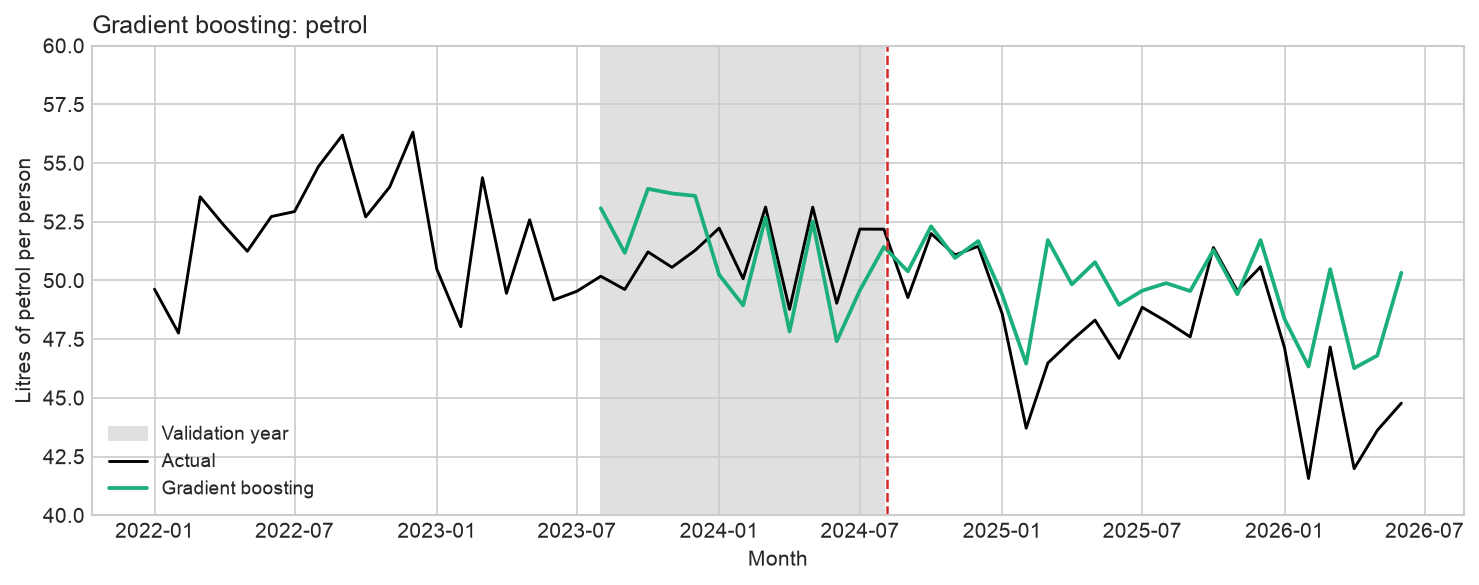

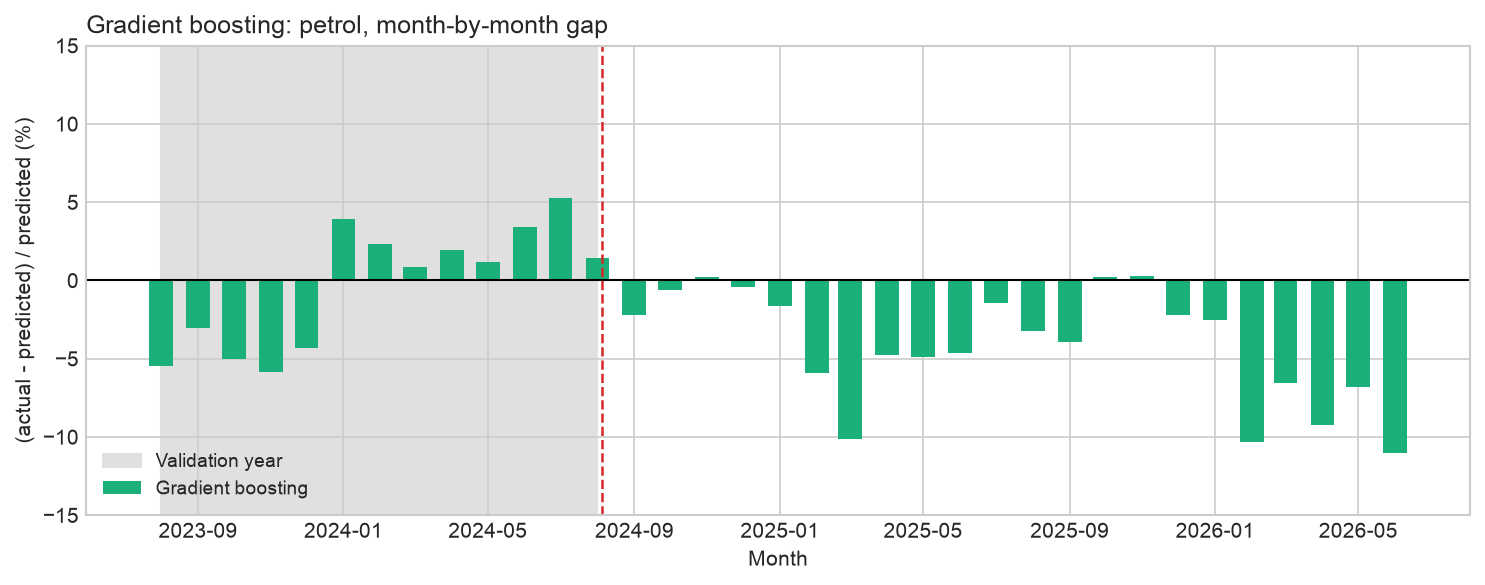

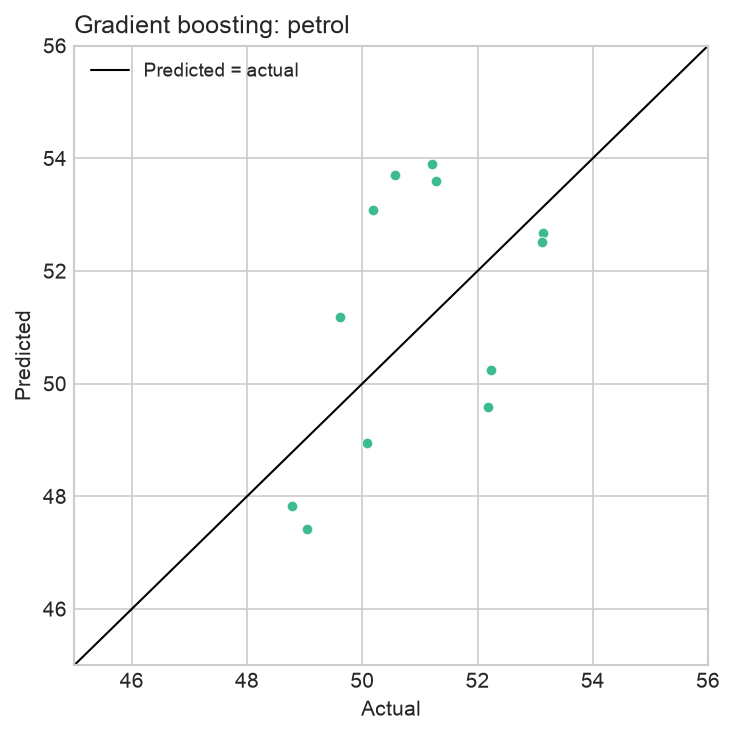

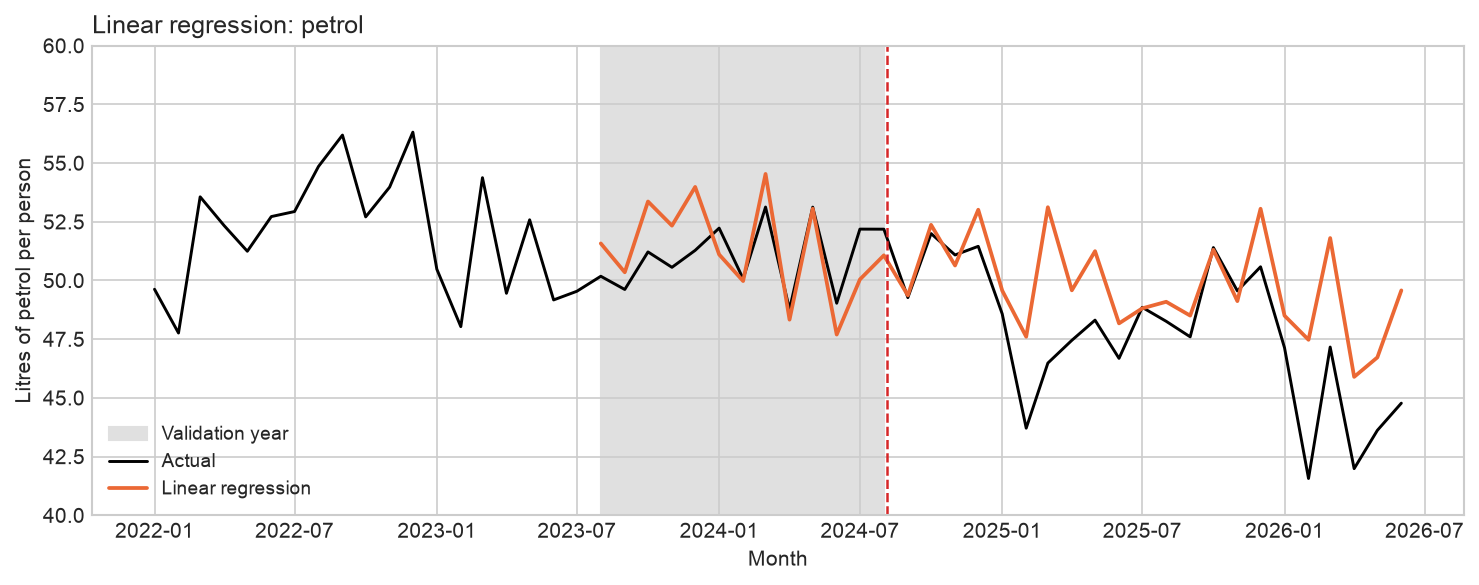

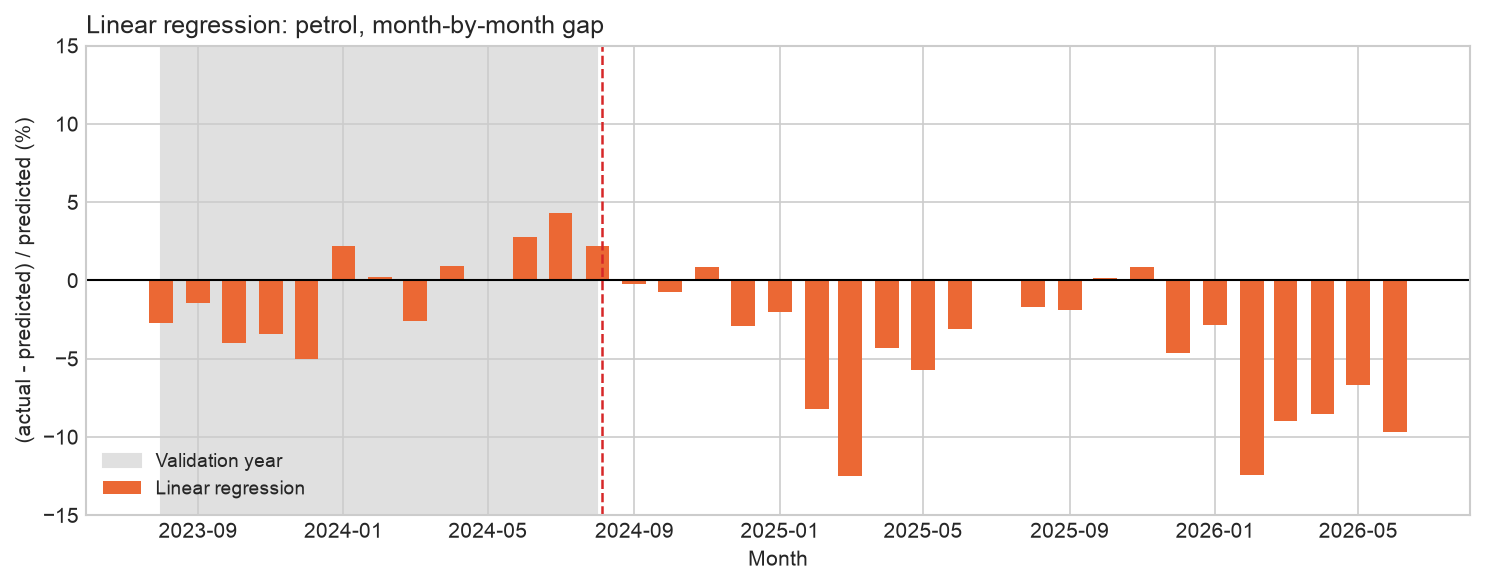

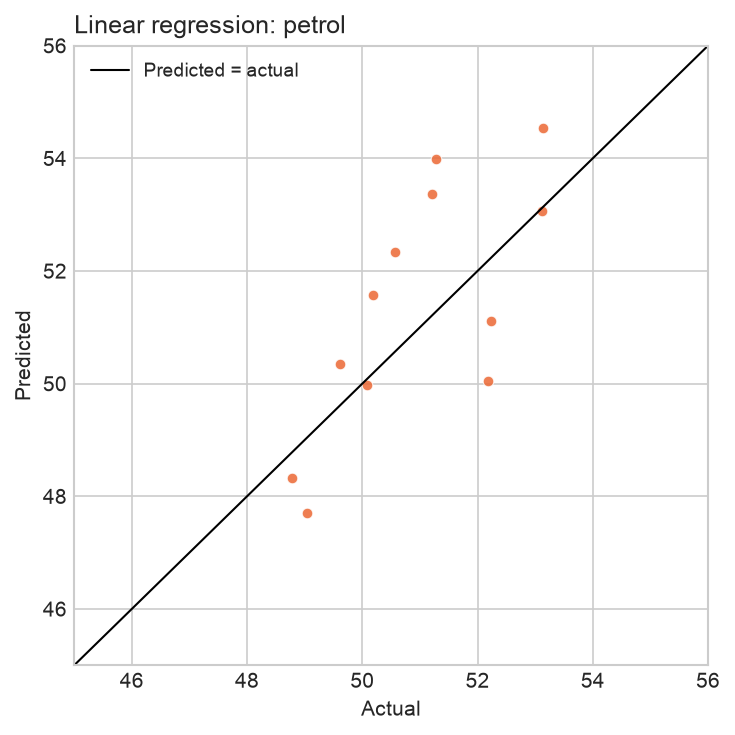

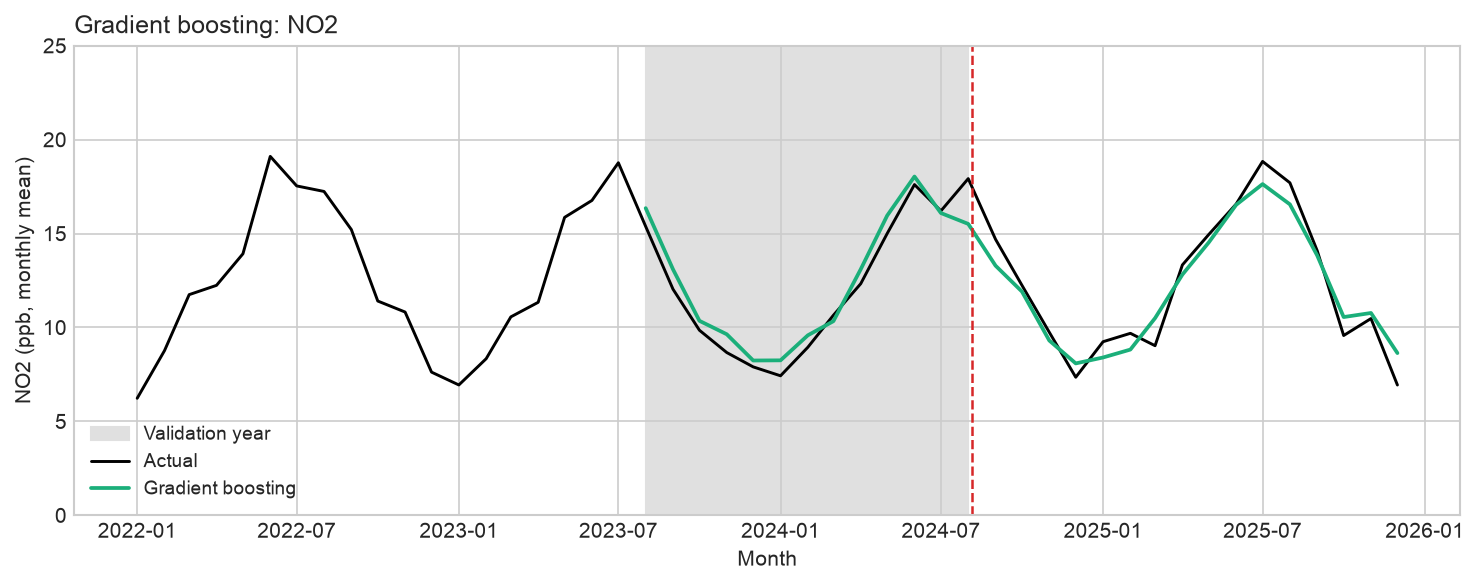

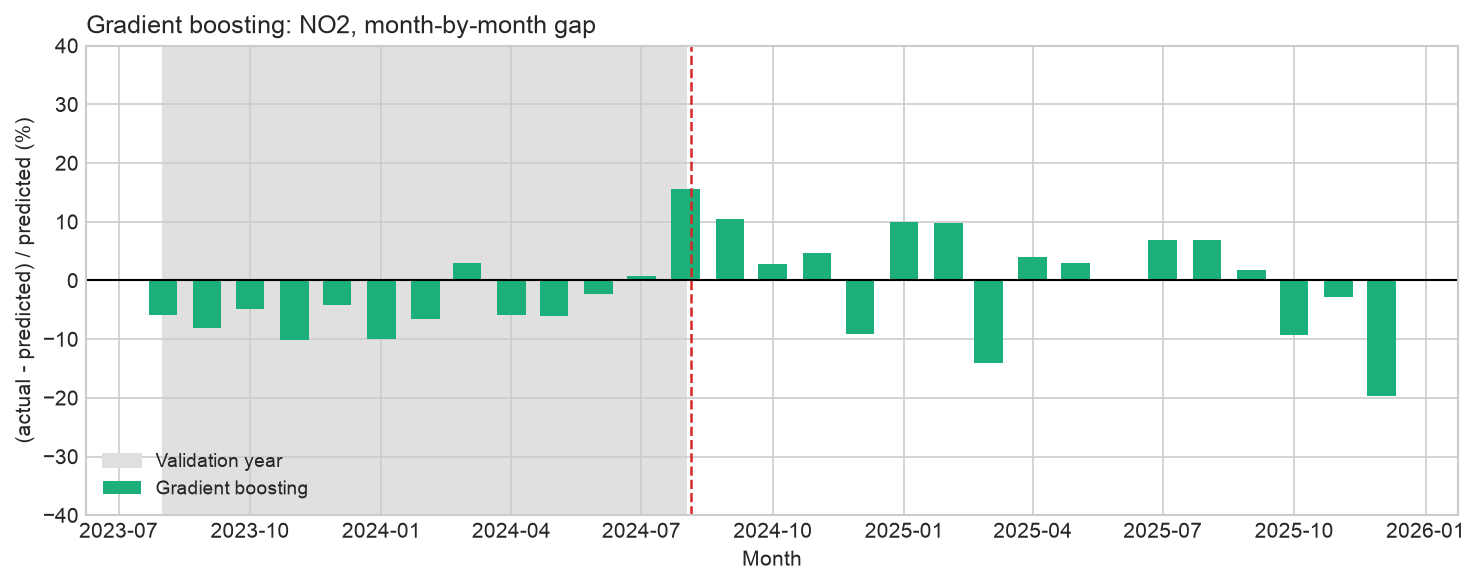

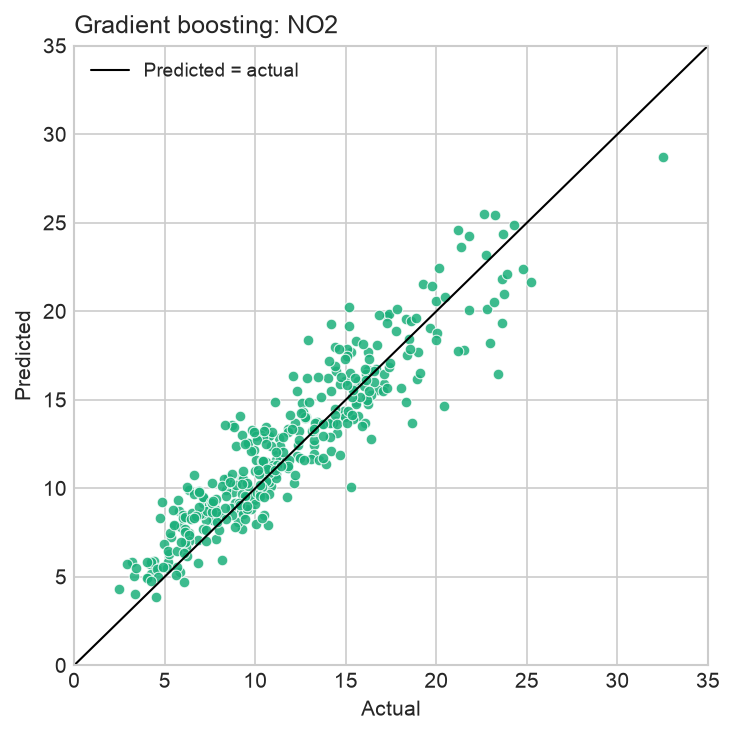

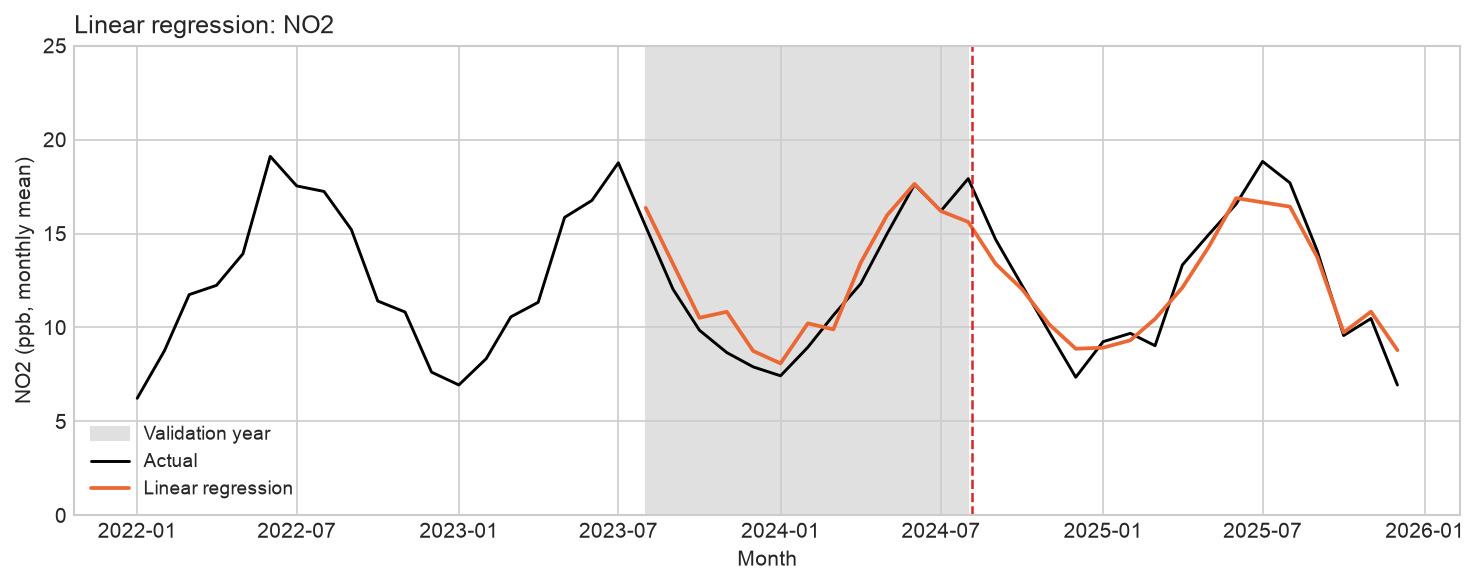

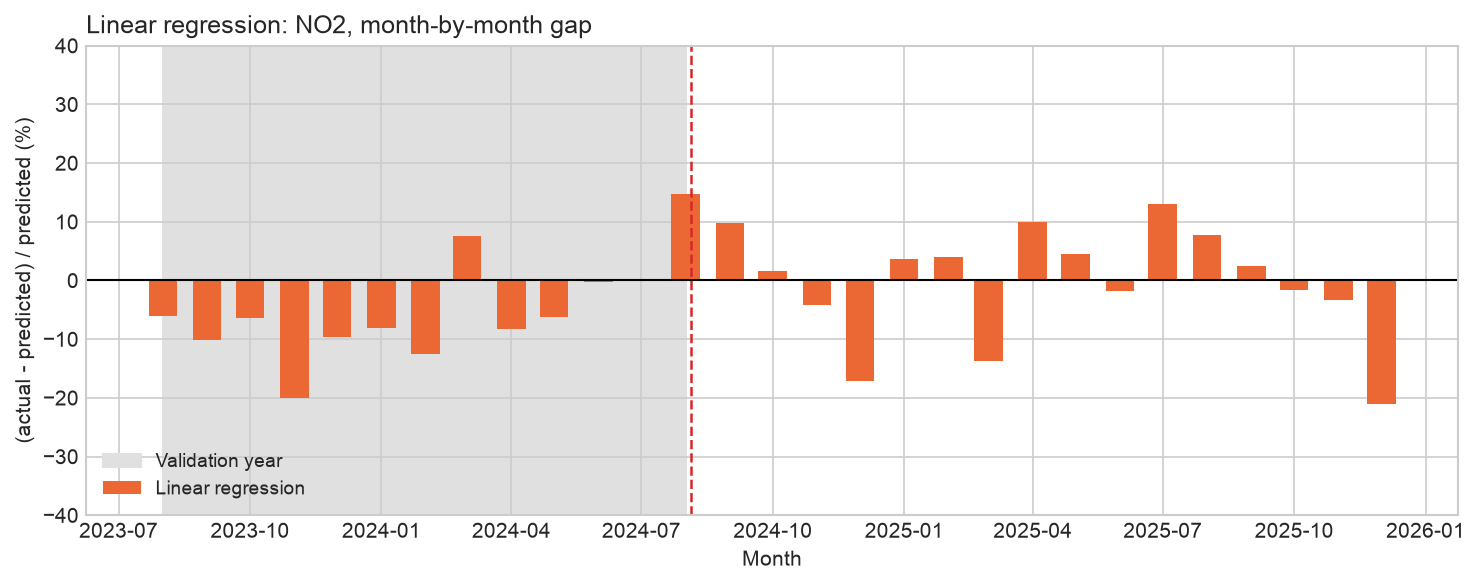

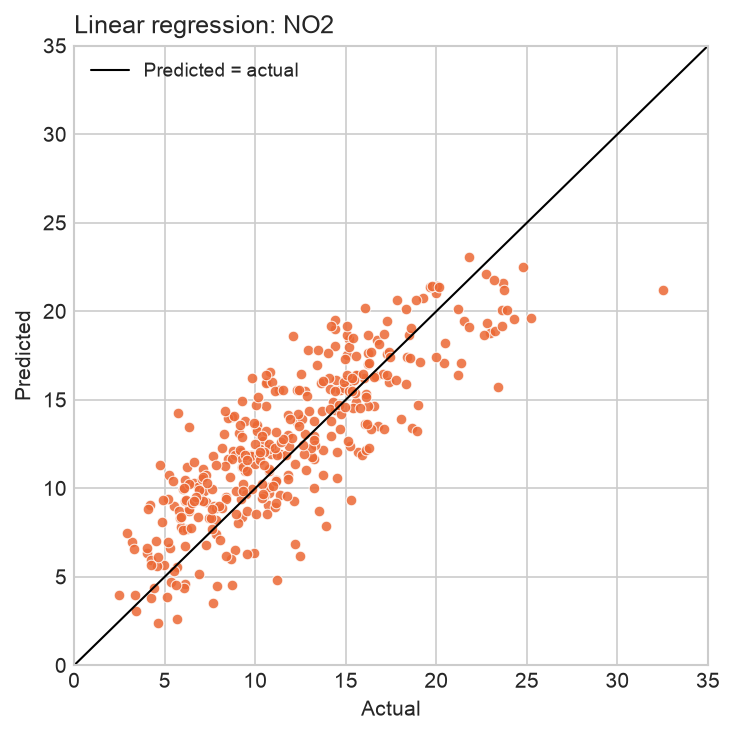

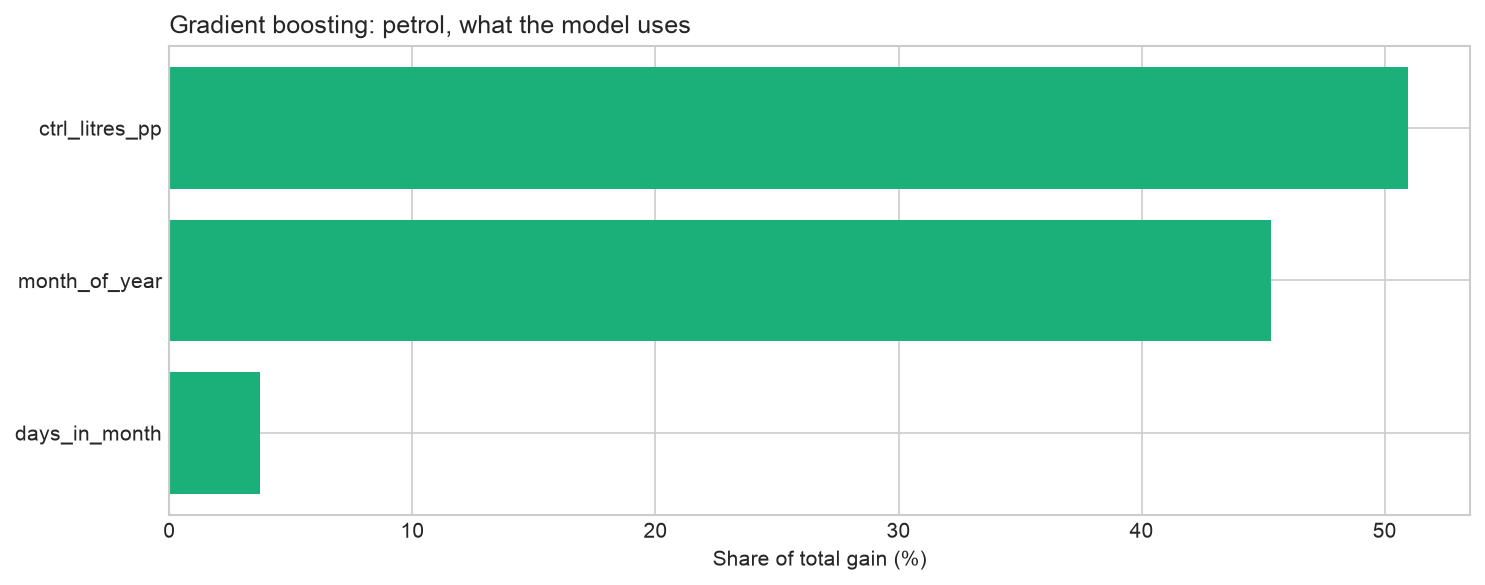

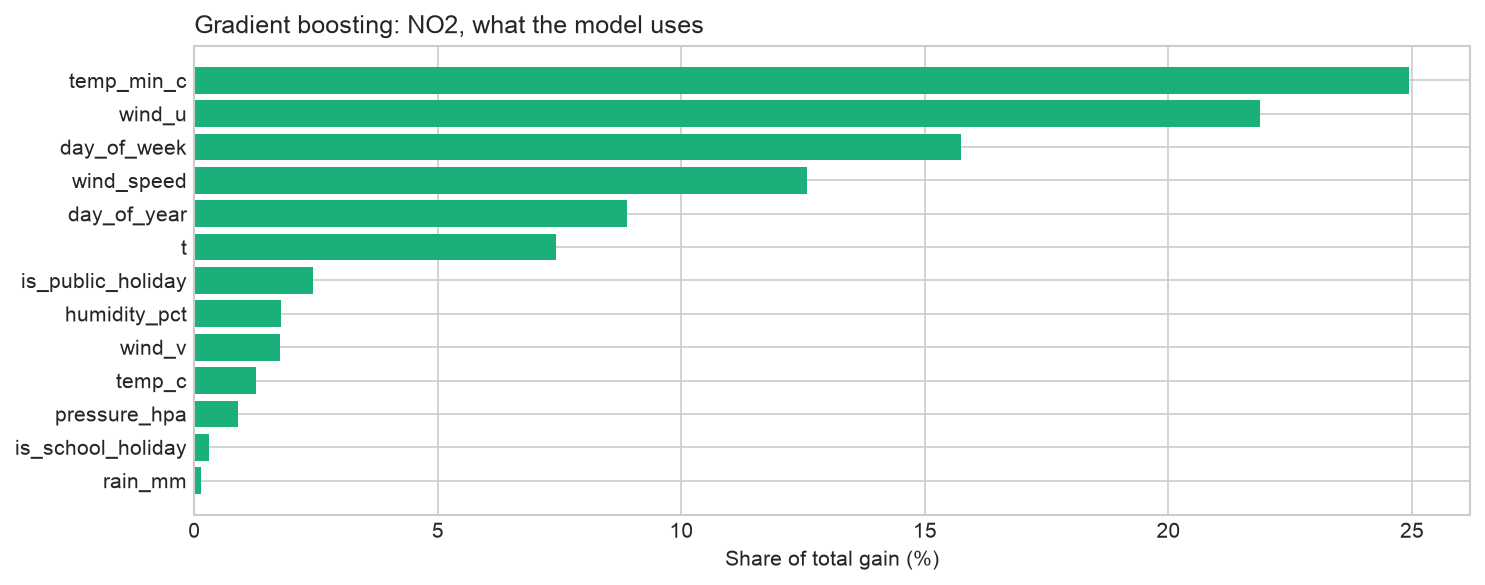

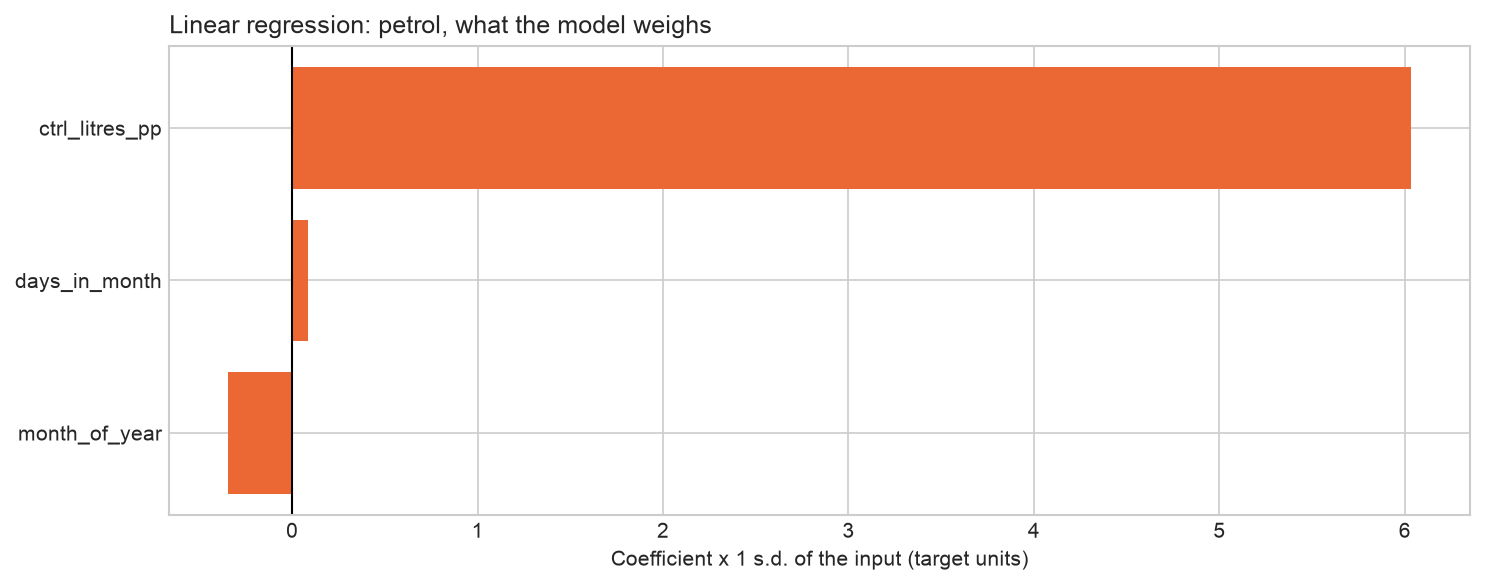

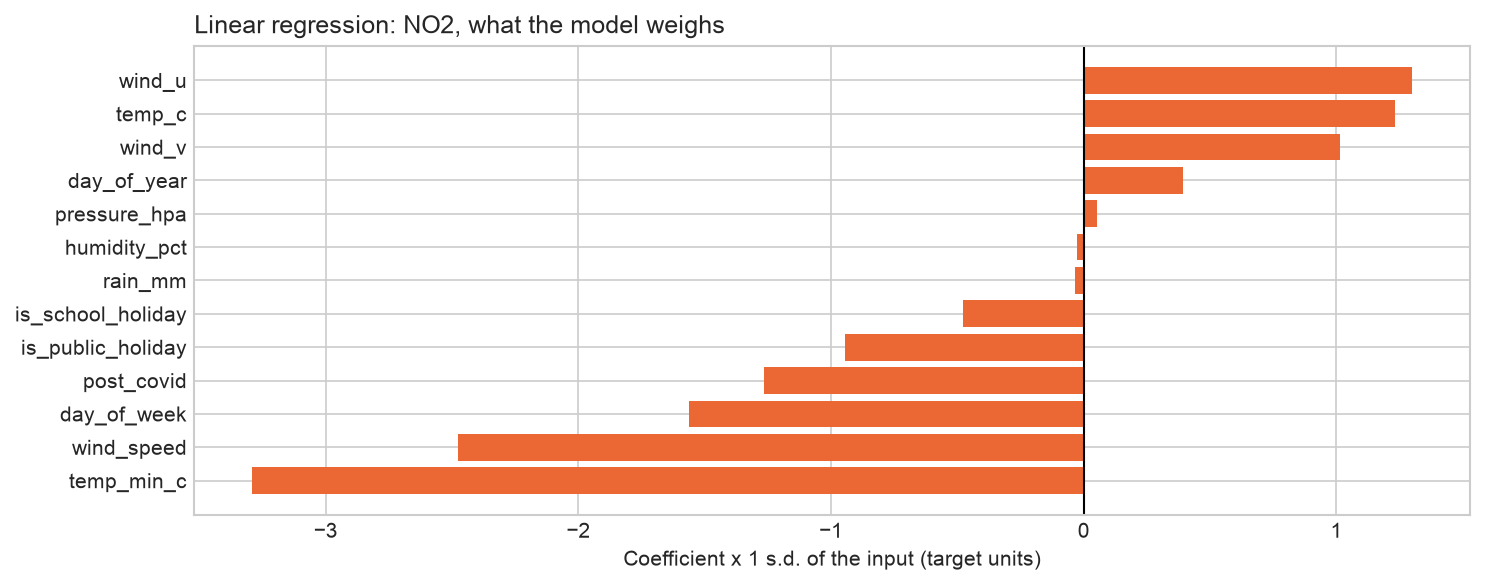

In [71]:
# Chart 1, 2 and 3 for each model, each file. The axis limits come from the
# guide, so every member's charts can be laid out side by side.
FILES = {
    'petrol': dict(
        preds={'Gradient boosting': petrol_gb, 'Linear regression': petrol_lr},
        ylabel='Litres of petrol per person',
        time_ylim=(40, 60), gap_ylim=(-15, 15), scatter_lim=(45, 56)),
    'NO2': dict(
        preds={'Gradient boosting': no2_gb, 'Linear regression': no2_lr},
        ylabel='NO2 (ppb, monthly mean)',
        time_ylim=(0, 25), gap_ylim=(-40, 40), scatter_lim=(0, 35)),
}
SOURCE = {'petrol': (petrol, 'month', 'qld_litres_pp'), 'NO2': (no2, 'date', 'no2_ppb')}

for file_name, spec in FILES.items():
    df, date_col, target = SOURCE[file_name]
    for model_name, look in MODELS.items():
        frame = curve(df, spec['preds'][model_name], date_col, target)
        stem = f'{look["tag"]}_{file_name.lower()}'
        chart_time(frame, look['colour'], model_name, spec['ylabel'], spec['time_ylim'],
                   f'{model_name}: {file_name}', MODEL_OUT / f'{stem}_1.png')
        chart_gap(frame, look['colour'], model_name, spec['gap_ylim'],
                  f'{model_name}: {file_name}, month-by-month gap', MODEL_OUT / f'{stem}_2.png')
        chart_scatter(spec['preds'][model_name], look['colour'], model_name,
                      spec['scatter_lim'], f'{model_name}: {file_name}',
                      MODEL_OUT / f'{stem}_3.png')

# The fourth chart, which differs by model: what the tree splits on, and what the
# straight line weighs.
chart_importance(petrol_gb_model, PETROL_INPUTS, MODELS['Gradient boosting']['colour'],
                 'Gradient boosting: petrol, what the model uses',
                 MODEL_OUT / 'boosting_petrol_4_importance.png')
chart_importance(no2_gb_model, NO2_INPUTS, MODELS['Gradient boosting']['colour'],
                 'Gradient boosting: NO2, what the model uses',
                 MODEL_OUT / 'boosting_no2_4_importance.png')
chart_coefficients(petrol_lr_model, MODELS['Linear regression']['colour'],
                   'Linear regression: petrol, what the model weighs',
                   MODEL_OUT / 'linear_petrol_4_coefficients.png')
chart_coefficients(no2_lr_model, MODELS['Linear regression']['colour'],
                   'Linear regression: NO2, what the model weighs',
                   MODEL_OUT / 'linear_no2_4_coefficients.png')


In [72]:
# The guide's combined charts need one CSV per model per file, main run only,
# carrying the validation and policy rows.
for (model_name, file_name, run), preds in RUNS.items():
    if run != 'main':
        continue
    path = MODEL_OUT / f'{MODELS[model_name]["tag"]}_{file_name.lower()}_predictions.csv'
    preds[['date', 'actual', 'predicted', 'split']].to_csv(path, index=False)
    print(f'{path.relative_to(ROOT)}: {len(preds)} rows '
          f'({(preds["split"] == "validation").sum()} validation, '
          f'{(preds["split"] == "policy").sum()} policy)')


model_ready/outputs/boosting_petrol_predictions.csv: 35 rows (12 validation, 23 policy)
model_ready/outputs/boosting_no2_predictions.csv: 867 rows (370 validation, 497 policy)
model_ready/outputs/linear_petrol_predictions.csv: 35 rows (12 validation, 23 policy)
model_ready/outputs/linear_no2_predictions.csv: 867 rows (370 validation, 497 policy)


**The fuel price, which the input list leaves out.** §4.5 found the fuel price moving patronage
on its own, and across this window it was falling: 194.8 cpl in the year before the fare against
183.7 cpl after it, a fall of 11.1 cpl. Through §4.5's own coefficient that fall is worth -0.14 trips
per resident per month, and it pushes the gap the other way — a cheaper tank should have lifted
petrol use and closed the gap, not opened it. The scale is what makes the check worth making: the
fare's fitted 0.638 trips per resident per month is the equivalent of about 51 cpl of fuel price, and
the whole range the price covers from here to the end of the window is 61.5 cpl. The two price
changes are the same size.

The price is not in the guide's input list for petrol, and it cannot be. It starts in January 2019,
so putting it in would cut the training rows from 93 to about 33 and leave almost no pre-fare period
to learn from. The model therefore cannot separate the two price changes, and what follows is a check
on the gap rather than a control for it: if the gap the model reports were a fuel-price artefact, it
should widen in the expensive months and close in the cheap ones.


In [73]:
# The fare is not the only price that moved across the policy window. The fuel price is
# not in the guide's input list for petrol, and cannot be: it starts in January 2019,
# which would cut the training rows from 93 to about 33 and leave almost no pre-fare
# period to learn from. So the model cannot separate the two price changes, and what
# follows is a check on the gap, not a control for it.
FUEL_PRE = pd.Timestamp('2023-12-01')     # the year before the fare
FUEL_FROM = pd.Timestamp('2024-08-01')    # the fare itself
FARE_COEF, FUEL_COEF = 0.6379, 0.0124     # section 4.5, trips per resident per month

fuel_price = petrol[['month', 'qld_ulp_price_cpl']]
fuel_before = fuel_price.loc[(fuel_price['month'] >= FUEL_PRE)
                             & (fuel_price['month'] < FUEL_FROM), 'qld_ulp_price_cpl']
fuel_after = fuel_price.loc[fuel_price['month'] >= FUEL_FROM, 'qld_ulp_price_cpl']
fuel_window = fuel_price.loc[fuel_price['month'] >= FUEL_PRE, 'qld_ulp_price_cpl']

print(f'Fuel price, the year before the fare against the policy window: '
      f'{fuel_before.mean():.1f} -> {fuel_after.mean():.1f} cpl '
      f'({fuel_after.mean() - fuel_before.mean():+.1f})')
print(f'  that fall is worth {(fuel_after.mean() - fuel_before.mean()) * FUEL_COEF:+.3f} trips per '
      f'resident per month through the coefficient fitted in 4.5, against the fare at {FARE_COEF:+.3f}')
print(f'  the fare at {FARE_COEF:.3f} trips is the equivalent of {FARE_COEF / FUEL_COEF:.0f} cpl of '
      f'fuel price; the whole range here is {fuel_window.max() - fuel_window.min():.1f} cpl, '
      f'{fuel_window.min():.1f} to {fuel_window.max():.1f}')


Fuel price, the year before the fare against the policy window: 194.8 -> 183.7 cpl (-11.1)
  that fall is worth -0.138 trips per resident per month through the coefficient fitted in 4.5, against the fare at +0.638
  the fare at 0.638 trips is the equivalent of 51 cpl of fuel price; the whole range here is 61.5 cpl, 166.4 to 227.9


In [74]:
# Does the gap the model reports actually track the price? If it were a fuel-price
# artefact, the expensive months should carry the deepest gaps.
fuel_gaps = []
for model_name in MODELS:
    preds = RUNS[(model_name, 'petrol', 'main')].merge(fuel_price, left_on='date', right_on='month')
    preds = preds[preds['split'] == 'policy'].copy()
    preds['gap'] = (preds['actual'] - preds['predicted']) / preds['predicted'] * 100
    fuel_gaps.append(preds.assign(model=model_name))
fuel_gaps = pd.concat(fuel_gaps, ignore_index=True)

for model_name, group in fuel_gaps.groupby('model'):
    r = group['gap'].corr(group['qld_ulp_price_cpl'])
    print(f'{model_name}: corr(monthly gap, price) = {r:+.2f} over {len(group)} policy months, '
          f'r2 = {r ** 2:.3f}, mean gap {group["gap"].mean():+.2f}%')

fuel_tree = fuel_gaps[fuel_gaps['model'] == 'Gradient boosting']
fmt = {'date': lambda d: d.strftime('%Y-%m'), 'gap': lambda g: f'{g:+.1f}%'}
for label, rows in [('deepest', fuel_tree.nsmallest(3, 'gap')),
                    ('dearest', fuel_tree.nlargest(3, 'qld_ulp_price_cpl'))]:
    print(f'\nThe three {label} policy months, tree model:')
    print(rows[['date', 'qld_ulp_price_cpl', 'gap']].to_string(index=False, formatters=fmt))

first = fuel_tree[fuel_tree['date'] < '2025-08-01']['gap'].mean()
second = fuel_tree[fuel_tree['date'] >= '2025-08-01']['gap'].mean()
print(f'\nTree model mean gap: {first:+.2f}% over the first policy year, {second:+.2f}% over the second')


Gradient boosting: corr(monthly gap, price) = -0.09 over 23 policy months, r2 = 0.008, mean gap -3.93%
Linear regression: corr(monthly gap, price) = -0.19 over 23 policy months, r2 = 0.035, mean gap -4.03%

The three deepest policy months, tree model:
   date  qld_ulp_price_cpl    gap
2026-06             166.43 -11.0%
2026-02             169.45 -10.3%
2025-03             190.48 -10.1%

The three dearest policy months, tree model:
   date  qld_ulp_price_cpl    gap
2026-03             227.94  -6.6%
2026-04             207.75  -9.2%
2025-03             190.48 -10.1%

Tree model mean gap: -2.91% over the first policy year, -5.03% over the second


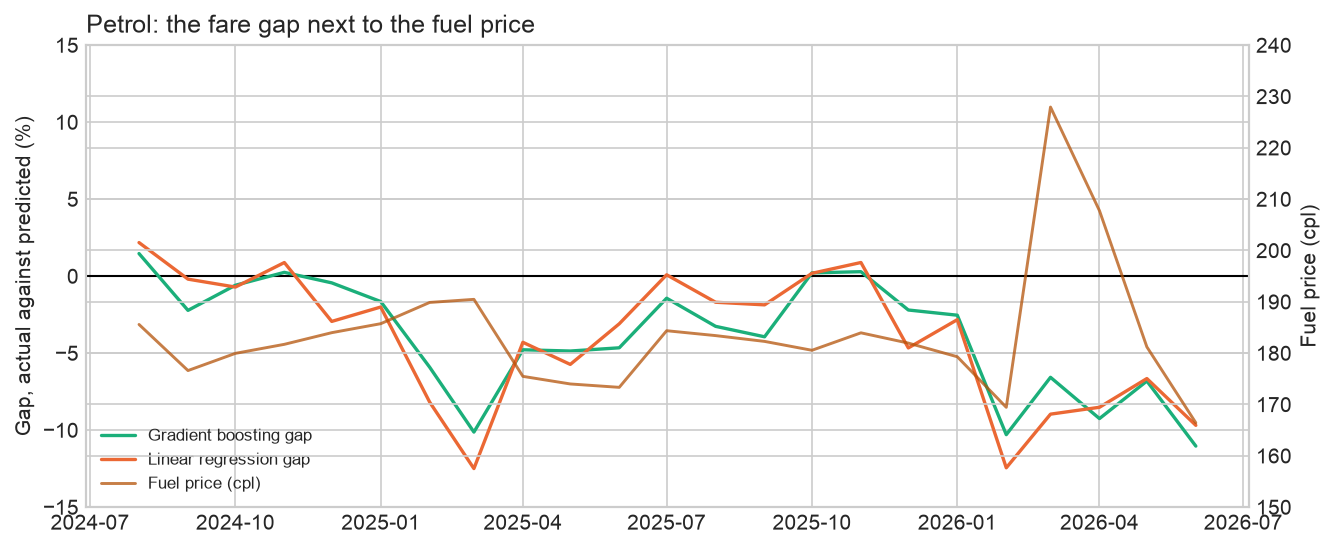

In [75]:
# The same policy months as chart 2, with the fuel price drawn over them on the right
# axis. If the gap were tracking the price the two would move together; they do not.
fig, ax = plt.subplots(figsize=(10, 4))
ax.axhline(0, color='black', lw=1)
fuel_lines = []
for model_name, look in MODELS.items():
    group = fuel_gaps[fuel_gaps['model'] == model_name]
    fuel_lines += ax.plot(group['date'], group['gap'], color=look['colour'], lw=1.6,
                          label=f'{model_name} gap')
ax.set_ylabel('Gap, actual against predicted (%)')
ax.set_ylim(-15, 15)
ax.set_title('Petrol: the fare gap next to the fuel price', loc='left')

fuel_ax = ax.twinx()
fuel_lines += fuel_ax.plot(fuel_tree['date'], fuel_tree['qld_ulp_price_cpl'], color='#b45309',
                           lw=1.4, alpha=0.75, label='Fuel price (cpl)')
fuel_ax.set_ylabel('Fuel price (cpl)')
fuel_ax.set_ylim(150, 240)

ax.legend(fuel_lines, [line.get_label() for line in fuel_lines], loc='lower left', fontsize=8)
save(fig, MODEL_OUT / 'petrol_fuel_price_check.png')


**What the check says.** The two do not move together. Across the 23 policy months the correlation
between the tree model's monthly gap and the fuel price is -0.09 — negative, the direction a
price-driven gap would take, but the price accounts for under 1% of the month-to-month movement, and
under 4% for the straight line at -0.19. The two cheapest months in the window are also the two
deepest gaps, June 2026 at 166.4 cpl and February 2026 at 169.4 cpl, while the dearest month of all,
March 2026 at 227.9 cpl, is shallower than both the month before it and the month after. That is the
opposite of a fuel bill moving the gap.

It rules out a simple price story; it does not isolate the fare. The price is still not in the model,
the window holds one fare change and one long fall in the price, and the gap deepens as the forecast
runs on — the tree model averages -2.9% over the first policy year and -5.0% over the second.
Whether that second half is the fare working or the model drifting is what the reading below has to
settle, and all this check tells us is that it is not the fuel price.


**Reading the two models.** *To be written once the section has been run.* The tuning tables,
the validation error and bias, the policy gap for both files and both runs, the fitted petrol
equation and the Durbin-Watson statistics are all printed above and written to
`model_ready/outputs/`. The reading takes the same line as §4.5: state the gap, put it beside the
error the model already carries on the validation year, and say plainly whether the two are
separable — a gap no larger than the model's own error on a year it never saw is not a result. The
comparison between the two models carries a second question: where they disagree about the gap, the
disagreement is about the shape of the pre-fare trend, and the tree model with the smaller error is
not automatically the better answer to a question about what would have happened. The fuel-price
check above settles one thing this reading has to account for: the gap is not the fuel price moving
under it, so the drift question stays open rather than closed.


---

**Step 5 — storytelling with data.**

**What we can say.** The fare moved patronage, and most of it stuck — and it is not population.
Trips rose on every mode after August 2024, in year-on-year terms and not merely as a seasonal
pattern. The rise is not a growing state being counted twice: Queensland's population added
about 1.7% a year, which accounts for about 1.7 of the 13.8 percentage points — roughly
one-eighth — leaving **11.8% per year per resident** for the fare to explain. The per-resident
regression puts the fare at 0.64 extra trips per resident per month (p < 0.001).

One caveat has to travel with that number. Population and the fare cannot be separated in a raw
levels regression, because over 29 months with only 8 pre-policy months a step that switches on
once is collinear with a steady upward trend — put both in and the fare coefficient halves and
loses significance. That is an identification failure, not evidence the fare did nothing. It is
why the per-resident specification, which divides population out before fitting, is the one to
quote rather than the levels model.

The persistence is uneven, and worth stating honestly rather than smoothing over. These are
per-resident figures. Bus (10.3% → 11.9%) held its gain into the second policy year and Ferry
(25.2% → 18.3%) kept most of its own, while Citytrain (18.2% → 4.6%) and Tram (24.0% → 7.9%)
fell back sharply — which looks less like a durable shift in commuting than a novelty response
that faded.

The two prices also act on different things. The fare is a policy step that changes how people
travel this week; petrol is a volatile cost that changes slowly what people drive and buy. Over
this window the fuel price shows no detectable relationship with registration counts, but it
does line up with a steady shift toward hybrid and electric cars, which is the channel where a
running cost plausibly matters. Car ownership did not visibly respond to the fare at all: new
registrations show no break at August 2024, which is consistent with the interpretation in the
broader project that the extra trips look largely discretionary rather than car commutes
replaced.

**What we cannot say.**

| Claim we would like to make | Why we cannot |
|---|---|
| "The fare cut caused a X% rise in patronage" | Only 8 pre-policy months (Dec 2023 – Jul 2024), so only the first policy year has a pre-policy year-on-year baseline; and no control state |
| "Higher petrol prices reduce car sales" | Effect not detectable at n≈23; confounded with the 2026 spike |
| "Queensland's fleet is going electric because of fuel prices" | The trend starts before the window and is nationwide |
| "The policy reduced emissions by Y tonnes" | Needs a driving measure (fuel sales, traffic counts), not ownership |

**What would strengthen this.** A longer patronage series reaching back before 2023 would give
the year-on-year comparison a real pre-policy baseline instead of one observation. A control
state — Victoria or New South Wales fares — would enable a difference-in-differences design,
and this is the single biggest gap. A direct driving measure, such as the monthly petrol sales
by state that the wider project already uses, would measure driving rather than only ownership.
And the used-vehicle transfers contained in the registration source, which we did not use,
would separate new-car demand from fleet churn.

**Known limitations of the data itself.**

| Issue | Effect on the analysis |
|---|---|
| Patronage is Southeast Queensland; fuel, registrations and population are all Queensland | Two mismatches. SEQ is roughly 70% of the state for fuel and registrations — and because SEQ grows faster than the state as a whole, dividing SEQ trips by *Queensland* population **overstates** trips per resident. The population-adjusted figure is therefore an upper bound, not a conservative one |
| Queensland population is quarterly, and the ABS file ends Mar 2026 | Interpolated to monthly, and the last two months (~0.2%) are extrapolated at the last observed growth rate. Small enough not to move the conclusion, but it is an assumption |
| Population is the whole state, so it cannot adjust for the age structure of the SEQ catchment | A growing state adds residents of all ages; if growth skews to areas or ages that travel less, the true per-resident effect is larger than measured, not smaller |
| Petrol prices are "changes only", forward-filled to daily | Early months average over fewer stations (1,491 in Sep 2023 vs ~1,590 by late 2025) |
| Station-level reporting frequency varies | Monthly means lean toward frequently-reporting sites |
| BITRE stock has three annual observations | Context only; cannot be modelled |
| Patronage counts trips, not people | One person can contribute many trips |
| Cyclone Alfred (Mar 2025) disrupted SEQ services | Creates a one-off dip that must be flagged, not modelled |